In [2]:
from pathlib import Path
import gc
import inspect
import random
import warnings

import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import ImageFile
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision enabled.")

2026-05-08 10:58:56.525122: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778237936.709686      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778237936.759970      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778237937.234195      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778237937.234240      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778237937.234242      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Mixed precision enabled.


In [3]:
# ─────────────────────────────────────────────────────────────
# SECTIE 0 — bovenaan je notebook, na de bestaande imports
# =============================================================
import wandb
from wandb.integration.keras import WandbMetricsLogger

WANDB_PROJECT = "lizard-classification"
WANDB_ENTITY  = None   # vul je W&B username/team in, of laat None voor de default

def init_wandb_run(backbone_name, phase="head", extra_config=None):
    """Start een nieuwe W&B run voor één backbone + phase."""
    config = {
        # Dataset
        "img_size":               IMG_SIZE,
        "val_size":               VAL_SIZE,
        "batch_size":             BATCH_SIZE,
        "num_classes":            len(class_names),
        "class_names":            class_names,
        "seed":                   SEED,
        # Model
        "backbone":               backbone_name,
        "phase":                  phase,
        "dense_units":            BEST_PARAMS["dense_units"],
        "dropout_rate":           BEST_PARAMS["dropout_rate"],
        "label_smoothing":        LABEL_SMOOTHING,
        "convnext_drop_path_rate":CONVNEXT_DROP_PATH_RATE,
        # Optimizer
        "optimizer":              BEST_PARAMS["optimizer"],
        "learning_rate":          BEST_PARAMS["learning_rate"],
        "weight_decay":           BEST_PARAMS["weight_decay"],
        # Epochs
        "head_epochs":            BEST_PARAMS["head_epochs"],
        "fine_tune_epochs":       BEST_PARAMS["fine_tune_epochs"],
        "fine_tune_last_n_layers":BEST_PARAMS["fine_tune_last_n_layers"],
        "fine_tune_lr":           BEST_PARAMS["fine_tune_learning_rate"],
        # Regularisatie
        "class_weight_power":     CLASS_WEIGHT_POWER,
        "val_score_loss_weight":  VAL_SCORE_LOSS_WEIGHT,
        "val_score_gap_weight":   VAL_SCORE_GAP_WEIGHT,
        # Augmentatie / TTA
        "use_tta":                USE_TTA,
        "use_enhanced_tta":       USE_ENHANCED_TTA,
        # Ensemble
        "ensemble_backbones":     ACTIVE_ENSEMBLE_BACKBONES,
        "ensemble_selection_mode":ENSEMBLE_SELECTION_MODE,
        "ensemble_optuna_trials": ENSEMBLE_WEIGHT_OPTUNA_TRIALS,
        # Brown/Green specialist
        "use_brown_green_specialist":           USE_BROWN_GREEN_SPECIALIST,
        "use_brown_green_pair_calibration":     USE_BROWN_GREEN_PAIR_CALIBRATION,
        "brown_green_class_weight_boost":       BROWN_GREEN_CLASS_WEIGHT_BOOST,
    }
    if extra_config:
        config.update(extra_config)

    run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=f"{backbone_name}_{phase}",
        group=backbone_name,          # groepeert head + fine_tune per backbone
        config=config,
        reinit=True,
    )
    return run


In [4]:
def show_kaggle_input_tree(max_lines=80):
    kaggle_input = Path("/kaggle/input")
    if not kaggle_input.exists():
        print("/kaggle/input does not exist in this runtime.")
        return
    shown = 0
    for path in sorted(kaggle_input.rglob("*")):
        depth = len(path.relative_to(kaggle_input).parts)
        if depth > 4:
            continue
        print("  " * depth + path.name + ("/" if path.is_dir() else ""))
        shown += 1
        if shown >= max_lines:
            print("...")
            break


def candidate_data_roots():
    candidates = [
        Path("/kaggle/input/lizard/AI-Lizard-Prediction-Challenge"),
        Path("/kaggle/input/lizard"),
        Path.cwd(),
        Path.cwd() / "AI-Lizard-Prediction-Challenge",
    ]
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates.extend(path for path in kaggle_input.rglob("*") if path.is_dir())
    seen = set()
    for candidate in candidates:
        try:
            resolved = candidate.resolve()
        except FileNotFoundError:
            continue
        if resolved not in seen:
            seen.add(resolved)
            yield resolved


def find_data_root():
    for candidate in candidate_data_roots():
        if (candidate / "train").is_dir() and (candidate / "test").is_dir():
            return candidate
    show_kaggle_input_tree()
    raise FileNotFoundError(
        "Could not find a data root containing train/ and test/. Attach the lizard dataset to this Kaggle notebook."
    )


def find_input_file(filename, data_root):
    search_roots = [data_root, data_root.parent, Path("/kaggle/input"), Path.cwd()]
    for root in search_roots:
        if not root.exists():
            continue
        direct = root / filename
        if direct.exists():
            return direct.resolve()
        if root.name == "input":
            matches = sorted(root.rglob(filename))
            if matches:
                return matches[0].resolve()
    return data_root / filename


DATA_ROOT = find_data_root()
WORKING_ROOT = Path("/kaggle/working") if Path("/kaggle/working").exists() else DATA_ROOT
WORKING_ROOT.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR = WORKING_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"
TRAIN_CSV = find_input_file("train.csv", DATA_ROOT)
TEST_CSV = find_input_file("test.csv", DATA_ROOT)

IMG_SIZE = (448, 448)  # 448 behoudt meer details in kop/schubben dan 224/384
BACKBONE_NAME = "convnext_tiny"  # options: "convnext_tiny", "efficientnetv2s", "efficientnetb0", "efficientnetv2b0"
CONVNEXT_DROP_PATH_RATE = 0.30  # iets meer stochastic depth tegen overfitting bij ConvNeXt
LABEL_SMOOTHING = 0.07  # iets meer regularisatie: helpt tegen overconfident voorspellen / hoge val_loss
ENSEMBLE_BACKBONES = ["convnext_tiny", "efficientnetv2s", "efficientnetb0"]
SKIP_ENSEMBLE_BACKBONES = []  # strong mode: train all listed backbones
ACTIVE_ENSEMBLE_BACKBONES = [
    backbone_name for backbone_name in ENSEMBLE_BACKBONES
    if backbone_name not in set(SKIP_ENSEMBLE_BACKBONES)
]
ENSEMBLE_WEIGHTS = {"convnext_tiny": 0.45, "efficientnetv2s": 0.35, "efficientnetb0": 0.20}

ENSEMBLE_MODEL_PATHS = {}  # optional: pre-trained .keras checkpoints; empty means train all ensemble backbones
ENSEMBLE_WEIGHT_OPTUNA_TRIALS = 900
ENSEMBLE_SELECTION_MODE = "optuna"  # validation is duidelijk beter met Optuna; gebruik "robust" als Kaggle sterk afwijkt  # options: "manual", "optuna", "robust"
MANUAL_ENSEMBLE_WEIGHTS = {"convnext_tiny": 0.045900, "efficientnetv2s": 0.478701, "efficientnetb0": 0.475399}
ENSEMBLE_ROBUST_SELECTION_TOLERANCE = 0.003  # choose a stabler manual blend if it is within 0.5 macro-F1 points
ENSEMBLE_ROBUST_CANDIDATE_WEIGHTS = {
    "optuna": None,
    "stable_010_045_045": {"convnext_tiny": 0.10, "efficientnetv2s": 0.45, "efficientnetb0": 0.45},
    "stable_020_040_040": {"convnext_tiny": 0.20, "efficientnetv2s": 0.40, "efficientnetb0": 0.40},
    "equal_033_033_033": {"convnext_tiny": 1/3, "efficientnetv2s": 1/3, "efficientnetb0": 1/3},
    "no_convnext_000_050_050": {"convnext_tiny": 0.00, "efficientnetv2s": 0.50, "efficientnetb0": 0.50},
}
VAL_SIZE = 0.15
BATCH_SIZE = 16
CLASS_WEIGHT_POWER = 0.65  # behoudt class weights, maar maakt ze minder agressief voor stabielere val_loss
VAL_SCORE_LOSS_WEIGHT = 0.25  # checkpoint kiest niet blind hoogste F1, maar straft hoge val_loss licht af
VAL_SCORE_GAP_WEIGHT = 0.05  # straft grote train/val accuracy gap licht af
AUTOTUNE = tf.data.AUTOTUNE

RUN_OPTUNA = False
N_OPTUNA_TRIALS = 30
N_FOLDS = 5
OPTUNA_HEAD_MAX_EPOCHS = 12
OPTUNA_FINE_TUNE_MAX_EPOCHS = 12
FINAL_HEAD_EPOCHS = 18  # kortere head-training: val_loss begon bij jullie snel te plateauën
FINAL_FORCE_FINE_TUNING = True
FINAL_FINE_TUNE_LAST_N_LAYERS = 12  # minder lagen unfreezen = minder ImageNet-kennis kapotmaken
FINAL_FINE_TUNE_EPOCHS = 8  # korter fine-tunen + early stopping op gecombineerde score
FINAL_FINE_TUNE_LEARNING_RATE = 1e-6  # veel lager om overfitting/val_loss stijging te vermijden
FINAL_FINE_TUNE_LAST_N_LAYERS_BY_BACKBONE = {"convnext_tiny": 6, "efficientnetv2s": 8, "efficientnetb0": 12}
USE_TTA = True

# Fine-grained improvements for brown anole vs green anole.
# The boost is applied on top of balanced class weights, so class imbalance is still handled.
BROWN_GREEN_KEYWORDS = ("brown", "green", "anole")
BROWN_GREEN_CLASS_WEIGHT_BOOST = 1.05  # mild: focus op brown/green zonder de classifier te forceren
USE_ENHANCED_TTA = True
TTA_CENTRAL_CROP_FRACTIONS = (1.00, 0.94, 0.88)
USE_BROWN_GREEN_PAIR_CALIBRATION = True
PAIR_CALIBRATION_GRID = np.round(np.linspace(0.70, 1.45, 16), 3)

# Extra specialist voor het moeilijkste paar.
# Dit model wordt alleen gebruikt wanneer de 7-class ensemble zelf al twijfelt tussen brown/green.
USE_BROWN_GREEN_SPECIALIST = True
BROWN_GREEN_SPECIALIST_BACKBONE = "efficientnetb0"
BROWN_GREEN_SPECIALIST_DENSE_UNITS = 64
BROWN_GREEN_SPECIALIST_DROPOUT = 0.45
BROWN_GREEN_SPECIALIST_HEAD_EPOCHS = 16
BROWN_GREEN_SPECIALIST_FINE_TUNE_EPOCHS = 6
BROWN_GREEN_SPECIALIST_FINE_TUNE_LAST_N_LAYERS = 10
BROWN_GREEN_SPECIALIST_HEAD_LR = 1e-3
BROWN_GREEN_SPECIALIST_FINE_TUNE_LR = 8e-7
BROWN_GREEN_SPECIALIST_WEIGHT_DECAY = 1e-4
BROWN_GREEN_SPECIALIST_MIN_SAMPLES = 20
SPECIALIST_MIN_PAIR_MASS_GRID = np.round(np.linspace(0.25, 0.85, 13), 2)
SPECIALIST_BLEND_GRID = np.round(np.linspace(0.50, 1.00, 6), 2)
SPECIALIST_TOP2_ONLY_OPTIONS = [True, False]
EXPORT_HARD_VALIDATION_EXAMPLES = True

OPTUNA_BATCH_CHOICES = [16, 24, 32]
OPTUNA_DENSE_CHOICES = [64, 128, 256]

print("Data root:", DATA_ROOT)
print("Working root:", WORKING_ROOT)
print("Artifacts dir:", ARTIFACTS_DIR)
print("Run Optuna:", RUN_OPTUNA)
print("Optuna trials:", N_OPTUNA_TRIALS)
print("Optuna folds:", N_FOLDS)
print("Active ensemble backbones:", ACTIVE_ENSEMBLE_BACKBONES)
print("Skipped ensemble backbones:", SKIP_ENSEMBLE_BACKBONES)

assert TRAIN_DIR.exists(), f"Missing training directory: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Missing test directory: {TEST_DIR}"
assert TRAIN_CSV.exists(), f"Missing train CSV: {TRAIN_CSV}"
assert TEST_CSV.exists(), f"Missing test CSV: {TEST_CSV}"

Data root: /kaggle/input/competitions/lizard-prediction-thomas-more
Working root: /kaggle/working
Artifacts dir: /kaggle/working/artifacts
Run Optuna: False
Optuna trials: 30
Optuna folds: 5
Active ensemble backbones: ['convnext_tiny', 'efficientnetv2s', 'efficientnetb0']
Skipped ensemble backbones: []


In [5]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")


def list_image_files(directory, extensions=IMAGE_EXTENSIONS):
    return sorted(path for path in Path(directory).rglob("*") if path.suffix.lower() in extensions)


def build_image_lookup(directory):
    return {path.name.casefold(): path for path in list_image_files(directory)}


def resolve_image_path(image_id, lookup):
    image_id = str(image_id)
    candidates = [image_id, Path(image_id).name]
    if Path(image_id).suffix == "":
        candidates.extend(f"{image_id}{extension}" for extension in IMAGE_EXTENSIONS)
    for candidate in candidates:
        resolved = lookup.get(candidate.casefold())
        if resolved is not None:
            return resolved
    return None


train_csv = pd.read_csv(TRAIN_CSV)
test_csv = pd.read_csv(TEST_CSV)
train_lookup = build_image_lookup(TRAIN_DIR)
test_lookup = build_image_lookup(TEST_DIR)

train_csv["filepath"] = train_csv["id"].map(lambda image_id: resolve_image_path(image_id, train_lookup))
missing_train = train_csv[train_csv["filepath"].isna()]
if len(missing_train) > 0:
    print(f"Skipping {len(missing_train)} train rows without a matching image file.")
df = train_csv[train_csv["filepath"].notna()].copy().reset_index(drop=True)
df["filepath"] = df["filepath"].astype(str)
df["label"] = df["label"].astype(int)

class_labels = sorted(df["label"].unique())
class_names = [
    df.loc[df["label"] == label, "filepath"].map(lambda path: Path(path).parent.name).mode().iloc[0]
    for label in class_labels
]
id_to_class = {label: class_name for label, class_name in zip(class_labels, class_names)}

test_df = test_csv.copy()
test_df["filepath"] = test_df["id"].map(lambda image_id: resolve_image_path(image_id, test_lookup))
assert test_df["filepath"].notna().all(), "Some test ids could not be matched to image files."
test_df["filepath"] = test_df["filepath"].astype(str)

train_df, val_df = train_test_split(
    df,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=df["label"],
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Training rows: {len(df):,}")
print(f"Train split: {len(train_df):,}")
print(f"Validation split: {len(val_df):,}")
print(f"Test rows: {len(test_df):,}")
print("Class mapping:", id_to_class)

print("Class distribution:")
display(df.assign(label_name=df["label"].map(id_to_class))["label_name"].value_counts().to_frame("count"))

def detect_brown_green_class_ids(class_names):
    detected = []
    for class_id, class_name in enumerate(class_names):
        normalised = str(class_name).lower().replace("_", " ").replace("-", " ")
        if "anole" in normalised and ("brown" in normalised or "green" in normalised):
            detected.append(class_id)
    # fallback: if folder names are simply brown/green without anole
    if len(detected) < 2:
        detected = []
        for class_id, class_name in enumerate(class_names):
            normalised = str(class_name).lower().replace("_", " ").replace("-", " ")
            if "brown" in normalised or "green" in normalised:
                detected.append(class_id)
    return sorted(set(detected))

BROWN_GREEN_CLASS_IDS = detect_brown_green_class_ids(class_names)
print("Brown/green focus class ids:", BROWN_GREEN_CLASS_IDS)
print("Brown/green focus class names:", [class_names[i] for i in BROWN_GREEN_CLASS_IDS])


Training rows: 1,334
Train split: 1,133
Validation split: 201
Test rows: 326
Class mapping: {np.int64(0): 'Black_spiny_tailed_iguana', np.int64(1): 'Brown_anole', np.int64(2): 'Cuban_knight_anole', np.int64(3): 'Desert_iguana', np.int64(4): 'Green_anole', np.int64(5): 'Green_iguana', np.int64(6): 'Lesser_Antillean_iguana'}
Class distribution:


,count
label_name,
Black_spiny_tailed_iguana,199
Green_iguana,196
Lesser_Antillean_iguana,196
Brown_anole,193
Cuban_knight_anole,189
Desert_iguana,183
Green_anole,178


Brown/green focus class ids: [1, 4]
Brown/green focus class names: ['Brown_anole', 'Green_anole']


In [6]:
def decode_and_resize(path, label=None, img_size=IMG_SIZE):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image = tf.image.resize(image, img_size, method=tf.image.ResizeMethod.BICUBIC)
    image = tf.cast(image, tf.float32)
    image = tf.clip_by_value(image, 0.0, 255.0)
    if label is None:
        return image
    return image, tf.cast(label, tf.int32)


def make_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    paths = dataframe["filepath"].astype(str).values
    labels = dataframe["label"].astype(np.int32).values
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    return dataset.map(decode_and_resize, num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)


def make_inference_dataset(dataframe, batch_size=BATCH_SIZE):
    paths = dataframe["filepath"].astype(str).values
    dataset = tf.data.Dataset.from_tensor_slices(paths)
    return dataset.map(lambda path: decode_and_resize(path), num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)


def make_class_weight_dict(labels):
    classes = np.array(sorted(pd.Series(labels).unique()))
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=np.asarray(labels))
    return {int(class_id): float(weight) for class_id, weight in zip(classes, weights)}

def make_focused_class_weight_dict(labels, boost_class_ids=None, boost_factor=1.0):
    weights = make_class_weight_dict(labels)
    # Soft class weighting: class weights blijven behouden, maar extreme verschillen worden afgevlakt.
    # Dit voorkomt vaak dat train loss hard daalt terwijl val_loss blijft hangen/stijgt.
    power = float(globals().get("CLASS_WEIGHT_POWER", 1.0))
    if power != 1.0:
        weights = {class_id: float(weight) ** power for class_id, weight in weights.items()}
    boost_class_ids = set([] if boost_class_ids is None else [int(x) for x in boost_class_ids])
    for class_id in boost_class_ids:
        if class_id in weights:
            weights[class_id] = float(weights[class_id]) * float(boost_factor)
    # keep the average weight around 1, otherwise the effective learning rate changes too much
    if weights:
        mean_weight = float(np.mean(list(weights.values())))
        if mean_weight > 0:
            weights = {class_id: float(weight) / mean_weight for class_id, weight in weights.items()}
    return weights


In [7]:
def decode_and_resize(path, label=None, img_size=IMG_SIZE):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image = tf.image.resize(image, img_size, method=tf.image.ResizeMethod.BICUBIC)
    image = tf.cast(image, tf.float32)
    image = tf.clip_by_value(image, 0.0, 255.0)
    if label is None:
        return image
    return image, tf.cast(label, tf.int32)


def make_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    paths = dataframe["filepath"].astype(str).values
    labels = dataframe["label"].astype(np.int32).values
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    return dataset.map(decode_and_resize, num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)


def make_inference_dataset(dataframe, batch_size=BATCH_SIZE):
    paths = dataframe["filepath"].astype(str).values
    dataset = tf.data.Dataset.from_tensor_slices(paths)
    return dataset.map(lambda path: decode_and_resize(path), num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)


def make_class_weight_dict(labels):
    classes = np.array(sorted(pd.Series(labels).unique()))
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=np.asarray(labels))
    return {int(class_id): float(weight) for class_id, weight in zip(classes, weights)}

def make_focused_class_weight_dict(labels, boost_class_ids=None, boost_factor=1.0):
    weights = make_class_weight_dict(labels)
    # Soft class weighting: class weights blijven behouden, maar extreme verschillen worden afgevlakt.
    # Dit voorkomt vaak dat train loss hard daalt terwijl val_loss blijft hangen/stijgt.
    power = float(globals().get("CLASS_WEIGHT_POWER", 1.0))
    if power != 1.0:
        weights = {class_id: float(weight) ** power for class_id, weight in weights.items()}
    boost_class_ids = set([] if boost_class_ids is None else [int(x) for x in boost_class_ids])
    for class_id in boost_class_ids:
        if class_id in weights:
            weights[class_id] = float(weights[class_id]) * float(boost_factor)
    # keep the average weight around 1, otherwise the effective learning rate changes too much
    if weights:
        mean_weight = float(np.mean(list(weights.values())))
        if mean_weight > 0:
            weights = {class_id: float(weight) / mean_weight for class_id, weight in weights.items()}
    return weights


In [8]:
def make_data_augmentation():
    # Fine-grained lizard classes depend on shape, scale pattern, head/body structure and colour.
    # Omdat green anoles ook bruin kunnen zijn, mag het model kleur NIET als shortcut nemen.
    # Daarom gebruiken we matige kleuraugmentatie: genoeg om shortcut-learning te beperken,
    # maar niet zo zwaar dat subtiele patronen verdwijnen.
    return keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.045),
            layers.RandomTranslation(height_factor=0.04, width_factor=0.04),
            layers.RandomZoom(height_factor=(-0.06, 0.10), width_factor=(-0.06, 0.10)),
            # Niet te agressief op kleur: green anoles kunnen bruin zijn, dus kleur mag geen shortcut worden,
            # maar subtiele soortkenmerken mogen ook niet kapot geaugmenteerd worden.
            layers.RandomContrast(0.12),
            layers.RandomBrightness(0.07),
        ],
        name="shape_texture_colour_safe_augmentation",
    )


data_augmentation = make_data_augmentation()

BACKBONE_LAYER_NAMES = {
    "convnext_tiny": "convnext_tiny",
    "efficientnetb0": "efficientnetb0",
    "efficientnetv2b0": "efficientnetv2-b0",
    "efficientnetv2s": "efficientnetv2-s",
}
BACKBONE_BUILDERS = {
    "convnext_tiny": keras.applications.ConvNeXtTiny,
    "efficientnetb0": keras.applications.EfficientNetB0,
    "efficientnetv2b0": keras.applications.EfficientNetV2B0,
    "efficientnetv2s": keras.applications.EfficientNetV2S,
}
BACKBONE_LAYER_NAME = BACKBONE_LAYER_NAMES[BACKBONE_NAME]


def get_backbone_layer_name(backbone_name):
    return BACKBONE_LAYER_NAMES[backbone_name]


def get_optimizer(name="adam", learning_rate=3e-4, weight_decay=1e-4):
    name = name.lower()
    if name == "adamw":
        try:
            return keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay)
        except AttributeError:
            print("AdamW unavailable; falling back to Adam.")
            return keras.optimizers.Adam(learning_rate=learning_rate)
    if name == "adam":
        return keras.optimizers.Adam(learning_rate=learning_rate)
    raise ValueError(f"Unsupported optimizer: {name}")


def make_backbone(backbone_name, img_size):
    builder = BACKBONE_BUILDERS[backbone_name]
    supported_kwargs = inspect.signature(builder).parameters
    backbone_kwargs = {
        "include_top": False,
        "weights": "imagenet",
        "input_shape": (*img_size, 3),
        "pooling": "avg",
    }
    if "include_preprocessing" in supported_kwargs:
        backbone_kwargs["include_preprocessing"] = True
    if "name" in supported_kwargs:
        backbone_kwargs["name"] = get_backbone_layer_name(backbone_name)
    if backbone_name == "convnext_tiny" and "drop_path_rate" in supported_kwargs:
        backbone_kwargs["drop_path_rate"] = CONVNEXT_DROP_PATH_RATE
    try:
        return builder(**backbone_kwargs)
    except Exception as exc:
        print(f"Could not load ImageNet weights: {exc}")
        print("Falling back to random initialization.")
        backbone_kwargs["weights"] = None
        return builder(**backbone_kwargs)


@keras.utils.register_keras_serializable(package="Lizard")
class SparseCategoricalCrossentropyWithLabelSmoothing(keras.losses.Loss):
    def __init__(
        self,
        label_smoothing=0.0,
        from_logits=False,
        reduction="sum_over_batch_size",
        name="sparse_categorical_crossentropy_with_label_smoothing",
        dtype=None,
    ):
        super().__init__(name=name, reduction=reduction, dtype=dtype)
        self.label_smoothing = float(label_smoothing)
        self.from_logits = bool(from_logits)

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        num_classes = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(y_true, num_classes, dtype=y_pred.dtype)
        return keras.losses.categorical_crossentropy(
            y_true_one_hot,
            y_pred,
            from_logits=self.from_logits,
            label_smoothing=self.label_smoothing,
        )

    def get_config(self):
        config = super().get_config()
        config.update({"label_smoothing": self.label_smoothing, "from_logits": self.from_logits})
        return config


def sparse_categorical_crossentropy_loss(label_smoothing=LABEL_SMOOTHING):
    return SparseCategoricalCrossentropyWithLabelSmoothing(label_smoothing=label_smoothing)


def compile_classifier_model(model, learning_rate, optimizer_name="adam", weight_decay=1e-4):
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate, weight_decay),
        loss=sparse_categorical_crossentropy_loss(),
        metrics=["accuracy"],
    )


def set_backbone_fine_tuning(model, fine_tune_last_n_layers=0):
    backbone_name = getattr(model, "_backbone_name", BACKBONE_NAME)
    backbone = model.get_layer(get_backbone_layer_name(backbone_name))
    if fine_tune_last_n_layers <= 0:
        backbone.trainable = False
        for layer in backbone.layers:
            layer.trainable = False
        return

    backbone.trainable = True
    for layer in backbone.layers[:-fine_tune_last_n_layers]:
        layer.trainable = False
    for layer in backbone.layers[-fine_tune_last_n_layers:]:
        layer.trainable = True
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False


def build_model(
    num_classes,
    dense_units=0,
    dropout_rate=0.35,
    learning_rate=3e-4,
    optimizer_name="adam",
    weight_decay=1e-4,
    backbone_name=BACKBONE_NAME,
):
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")
    x = make_data_augmentation()(inputs)
    backbone = make_backbone(backbone_name, IMG_SIZE)
    backbone.trainable = False
    x = backbone(x, training=False)
    x = layers.BatchNormalization(name="embedding_batchnorm")(x)
    x = layers.GaussianNoise(0.025, name="embedding_noise")(x)
    regularizer = keras.regularizers.l2(float(weight_decay))
    if dense_units > 0:
        x = layers.Dense(
            dense_units,
            activation="relu",
            kernel_regularizer=regularizer,
            name="fine_grained_dense",
        )(x)
        x = layers.BatchNormalization(name="fine_grained_dense_bn")(x)
        x = layers.Dropout(dropout_rate * 0.50, name="fine_grained_dense_dropout")(x)
    x = layers.Dropout(dropout_rate, name="classifier_dropout")(x)
    x = layers.Activation("linear", dtype="float32", name="embedding_features")(x)
    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        kernel_regularizer=regularizer,
        name="class_probabilities",
    )(x)
    model = keras.Model(inputs, outputs, name=f"lizard_{backbone_name}")
    model._backbone_name = backbone_name
    compile_classifier_model(model, learning_rate, optimizer_name, weight_decay)
    return model

I0000 00:00:1778237974.536155      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [9]:
# Hardcoded parameters so final training can be rerun without launching the Optuna search.
BEST_PARAMS = {
    # V2 defaults: minder agressief dan de oude 5e-3/Dropout 0.50/geen Dense-head.
    # Dit generaliseert meestal beter bij kleine fine-grained datasets.
    "learning_rate": 5e-4,
    "dropout_rate": 0.48,
    "dense_units": 32,
    "optimizer": "adamw",
    "weight_decay": 2e-4,
    "batch_size": 16,
    "use_fine_tuning": True,
    "head_epochs": FINAL_HEAD_EPOCHS,
    "fine_tune_last_n_layers": FINAL_FINE_TUNE_LAST_N_LAYERS,
    "fine_tune_learning_rate": FINAL_FINE_TUNE_LEARNING_RATE,
    "fine_tune_epochs": FINAL_FINE_TUNE_EPOCHS,
}
print("Hardcoded parameters used for final training.")

if FINAL_FORCE_FINE_TUNING:
    BEST_PARAMS["use_fine_tuning"] = True
    BEST_PARAMS["fine_tune_last_n_layers"] = int(BEST_PARAMS.get("fine_tune_last_n_layers", FINAL_FINE_TUNE_LAST_N_LAYERS) or FINAL_FINE_TUNE_LAST_N_LAYERS)
    BEST_PARAMS["fine_tune_learning_rate"] = float(BEST_PARAMS.get("fine_tune_learning_rate", FINAL_FINE_TUNE_LEARNING_RATE) or FINAL_FINE_TUNE_LEARNING_RATE)
    BEST_PARAMS["fine_tune_epochs"] = int(BEST_PARAMS.get("fine_tune_epochs", FINAL_FINE_TUNE_EPOCHS) or FINAL_FINE_TUNE_EPOCHS)

FINAL_HEAD_EPOCHS = int(BEST_PARAMS["head_epochs"])
BEST_PARAMS["head_epochs"] = FINAL_HEAD_EPOCHS
print("Final training params:")
print(pd.Series(BEST_PARAMS))

best_batch_size = int(BEST_PARAMS["batch_size"])
final_train_ds = make_dataset(train_df, batch_size=best_batch_size, shuffle=True)
final_val_ds = make_dataset(val_df, batch_size=best_batch_size)
final_class_weights = make_focused_class_weight_dict(
    train_df["label"].values,
    boost_class_ids=BROWN_GREEN_CLASS_IDS,
    boost_factor=BROWN_GREEN_CLASS_WEIGHT_BOOST,
)
print("Focused class weights used for training:")
display(pd.Series(final_class_weights).rename(index=id_to_class).to_frame("weight"))
final_val_labels = val_df["label"].to_numpy()
trained_model_paths = {}
training_histories = {}

if "ValidationMacroF1Callback" not in globals():
    class ValidationMacroF1Callback(keras.callbacks.Callback):
        def __init__(self, validation_data, validation_labels):
            super().__init__()
            self.validation_data = validation_data
            self.validation_labels = np.asarray(validation_labels)

        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            probabilities = self.model.predict(self.validation_data, verbose=0)
            predictions = probabilities.argmax(axis=1)
            logs["val_macro_f1"] = float(
                f1_score(self.validation_labels, predictions, average="macro")
            )

class WandbTrainingCallback(keras.callbacks.Callback):
    """
    Logt elke epoch naar W&B:
      - train loss / accuracy
      - val loss / accuracy
      - val_macro_f1  (als ValidationMacroF1Callback ook gebruikt wordt)
      - val_score     (als ValidationCompositeScoreCallback ook gebruikt wordt)
      - learning rate
    """
    def __init__(self, prefix=""):
        super().__init__()
        self.prefix = prefix  # bijv. "head/" of "fine_tune/"

    def on_epoch_end(self, epoch, logs=None):
        if not wandb.run:
            return
        logs = logs or {}
        metrics = {
            f"{self.prefix}epoch": epoch,
            f"{self.prefix}train_loss":      logs.get("loss"),
            f"{self.prefix}train_accuracy":  logs.get("accuracy"),
            f"{self.prefix}val_loss":        logs.get("val_loss"),
            f"{self.prefix}val_accuracy":    logs.get("val_accuracy"),
            f"{self.prefix}val_macro_f1":    logs.get("val_macro_f1"),
            f"{self.prefix}val_score":       logs.get("val_score"),
            f"{self.prefix}val_gen_gap":     logs.get("val_generalization_gap"),
            f"{self.prefix}lr":              float(
                keras.backend.get_value(self.model.optimizer.learning_rate)
            ),
        }
        # Verwijder None-waarden
        wandb.log({k: v for k, v in metrics.items() if v is not None})

def make_cosine_decay_callback(initial_lr, epochs, mid_lr=None, final_lr=None, fast_fraction=0.50, verbose=0):
    initial_lr = float(initial_lr)
    mid_lr = float(initial_lr * 0.10 if mid_lr is None else mid_lr)
    final_lr = float(mid_lr * 0.10 if final_lr is None else final_lr)
    total_epochs = max(int(epochs), 1)
    fast_steps = max(int(round((total_epochs - 1) * fast_fraction)), 1)
    slow_steps = max((total_epochs - 1) - fast_steps, 1)

    def cosine_decay(epoch, current_lr):
        if epoch <= fast_steps:
            progress = epoch / fast_steps
            cosine = 0.5 * (1.0 + np.cos(np.pi * progress))
            return float(mid_lr + (initial_lr - mid_lr) * cosine)

        progress = min(epoch - fast_steps, slow_steps) / slow_steps
        cosine = 0.5 * (1.0 + np.cos(np.pi * progress))
        return float(final_lr + (mid_lr - final_lr) * cosine)

    return keras.callbacks.LearningRateScheduler(cosine_decay, verbose=verbose)


def make_final_callbacks(checkpoint_path, initial_lr, epochs, patience=4, phase="head"):
    class ValidationCompositeScoreCallback(keras.callbacks.Callback):
        def __init__(self, loss_weight=None, gap_weight=None):
            super().__init__()
            self.loss_weight = float(globals().get("VAL_SCORE_LOSS_WEIGHT", 0.25) if loss_weight is None else loss_weight)
            self.gap_weight = float(globals().get("VAL_SCORE_GAP_WEIGHT", 0.05) if gap_weight is None else gap_weight)

        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            val_macro_f1 = float(logs.get("val_macro_f1", 0.0))
            val_loss = float(logs.get("val_loss", 0.0))
            train_acc = float(logs.get("accuracy", 0.0))
            val_acc = float(logs.get("val_accuracy", 0.0))
            generalization_gap = max(train_acc - val_acc, 0.0)
            # Hoog is goed. F1 blijft belangrijk, maar val_loss en train/val-gap worden sterker bestraft.
            # Daardoor kiezen we minder snel een checkpoint dat vooral de train set memoriseert.
            logs["val_generalization_gap"] = generalization_gap
            logs["val_score"] = val_macro_f1 - self.loss_weight * val_loss - self.gap_weight * generalization_gap

    min_lr = max(float(initial_lr) * 0.01, 1e-8)
    val_loss_patience = 3 if phase == "fine_tune" else 4
    val_score_patience = patience
    return [
        ValidationMacroF1Callback(final_val_ds, final_val_labels),
        ValidationCompositeScoreCallback(),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.35,
            patience=1 if phase == "fine_tune" else 2,
            min_delta=0.002,
            min_lr=min_lr,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_score",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=val_loss_patience,
            min_delta=0.002,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_score",
            mode="max",
            patience=val_score_patience,
            min_delta=0.001,
            restore_best_weights=True,
            verbose=1,
        ),
    ]


def get_fine_tune_last_n_layers(backbone_name):
    by_backbone = globals().get("FINAL_FINE_TUNE_LAST_N_LAYERS_BY_BACKBONE", {})
    return int(by_backbone.get(backbone_name, BEST_PARAMS.get("fine_tune_last_n_layers", FINAL_FINE_TUNE_LAST_N_LAYERS)))



def train_one_backbone(backbone_name):
    checkpoint_path = WORKING_ROOT / f"best_lizard_model_{backbone_name}.keras"
    external_checkpoint = ENSEMBLE_MODEL_PATHS.get(backbone_name)
    if external_checkpoint and Path(external_checkpoint).exists():
        print(f"Using pre-trained checkpoint for {backbone_name}: {external_checkpoint}")
        return Path(external_checkpoint), None, None

    print(f"\n=== Training ensemble backbone: {backbone_name} ===")

    # ── W&B run starten voor de head phase ──────────────────────
    run = init_wandb_run(backbone_name, phase="head")

    model = build_model(
        num_classes=len(class_names),
        dense_units=int(BEST_PARAMS["dense_units"]),
        dropout_rate=float(BEST_PARAMS["dropout_rate"]),
        learning_rate=float(BEST_PARAMS["learning_rate"]),
        optimizer_name=BEST_PARAMS["optimizer"],
        weight_decay=float(BEST_PARAMS["weight_decay"]),
        backbone_name=backbone_name,
    )

    head_callbacks = make_final_callbacks(
        checkpoint_path,
        initial_lr=float(BEST_PARAMS["learning_rate"]),
        epochs=int(BEST_PARAMS["head_epochs"]),
        patience=5,
        phase="head",
    )
    head_callbacks.append(WandbTrainingCallback(prefix="head/"))

    head_history = model.fit(
        final_train_ds,
        validation_data=final_val_ds,
        epochs=int(BEST_PARAMS["head_epochs"]),
        callbacks=head_callbacks,
        class_weight=final_class_weights,
        verbose=1,
    )

    # Beste head-metrics loggen als summary
    if head_history and head_history.history.get("val_macro_f1"):
        best_head_f1 = max(head_history.history["val_macro_f1"])
        wandb.summary["head/best_val_macro_f1"] = best_head_f1

    # ── Fine-tuning phase ────────────────────────────────────────
    fine_tune_history = None
    if bool(BEST_PARAMS.get("use_fine_tuning", False)):
        run.finish()   # sluit de head run

        fine_tune_layers = get_fine_tune_last_n_layers(backbone_name)
        run = init_wandb_run(backbone_name, phase="fine_tune",
                             extra_config={"fine_tune_layers_unfrozen": fine_tune_layers})

        print(f"Fine-tuning only the last {fine_tune_layers} layers for {backbone_name}.")
        set_backbone_fine_tuning(model, fine_tune_layers)
        compile_classifier_model(
            model,
            learning_rate=float(BEST_PARAMS["fine_tune_learning_rate"]),
            optimizer_name=BEST_PARAMS["optimizer"],
            weight_decay=float(BEST_PARAMS["weight_decay"]),
        )

        ft_callbacks = make_final_callbacks(
            checkpoint_path,
            initial_lr=float(BEST_PARAMS["fine_tune_learning_rate"]),
            epochs=int(BEST_PARAMS["fine_tune_epochs"]),
            patience=3,
            phase="fine_tune",
        )
        ft_callbacks.append(WandbTrainingCallback(prefix="fine_tune/"))

        fine_tune_history = model.fit(
            final_train_ds,
            validation_data=final_val_ds,
            epochs=int(BEST_PARAMS["fine_tune_epochs"]),
            callbacks=ft_callbacks,
            class_weight=final_class_weights,
            verbose=1,
        )

        if fine_tune_history and fine_tune_history.history.get("val_macro_f1"):
            best_ft_f1 = max(fine_tune_history.history["val_macro_f1"])
            wandb.summary["fine_tune/best_val_macro_f1"] = best_ft_f1

    # ── Model als W&B artifact opslaan ──────────────────────────
    if checkpoint_path.exists():
        print("Saved best checkpoint:", checkpoint_path)
    else:
        model.save(checkpoint_path)
        print("Saved final model:", checkpoint_path)

    artifact = wandb.Artifact(
        name=f"lizard-model-{backbone_name}",
        type="model",
        description=f"Best checkpoint for {backbone_name} after head + fine-tune",
        metadata={
            "backbone": backbone_name,
            "val_macro_f1": wandb.summary.get("fine_tune/best_val_macro_f1")
                            or wandb.summary.get("head/best_val_macro_f1"),
        },
    )
    artifact.add_file(str(checkpoint_path))
    run.log_artifact(artifact)

    run.finish()

    del model
    gc.collect()
    keras.backend.clear_session()
    return checkpoint_path, head_history, fine_tune_history



for backbone_name in ACTIVE_ENSEMBLE_BACKBONES:
    checkpoint_path, head_history, fine_tune_history = train_one_backbone(backbone_name)
    trained_model_paths[backbone_name] = checkpoint_path
    training_histories[backbone_name] = {"head": head_history, "fine_tune": fine_tune_history}

print("Ensemble checkpoints:")
print(pd.Series({name: str(path) for name, path in trained_model_paths.items()}))

Hardcoded parameters used for final training.
Final training params:
learning_rate                0.0005
dropout_rate                   0.48
dense_units                      32
optimizer                     adamw
weight_decay                 0.0002
batch_size                       16
use_fine_tuning                True
head_epochs                      18
fine_tune_last_n_layers          12
fine_tune_learning_rate    0.000001
fine_tune_epochs                  8
dtype: object
Focused class weights used for training:


,weight
Black_spiny_tailed_iguana,0.957623
Brown_anole,1.025326
Cuban_knight_anole,0.988290
Desert_iguana,1.012991
Green_anole,1.081871
Green_iguana,0.968837
Lesser_Antillean_iguana,0.965062



=== Training ensemble backbone: convnext_tiny ===


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


...

Fine-tuning only the last 12 layers for efficientnetb0.
Epoch 1/8


E0000 00:00:1778240044.626151      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/lizard_efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.7180 - loss: 0.9995
Epoch 1: val_score improved from -inf to 0.52325, saving model to /kaggle/working/best_lizard_model_efficientnetb0.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 44s 444ms/step - accuracy: 0.7181 - loss: 0.9996 - val_accuracy: 0.7562 - val_loss: 0.9325 - val_macro_f1: 0.7564 - val_generalization_gap: 0.0000e+00 - val_score: 0.5232 - learning_rate: 1.0000e-06
Epoch 2/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.6892 - loss: 1.0611
Epoch 2: ReduceLROnPlateau reducing learning rate to 3.4999999911633493e-07.

Epoch 2: val_score improved from 0.52325 to 0.52346, saving model to /kaggle/working/best_lizard_model_efficientnetb0.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 24s 332ms/step - accuracy: 0.6892 - loss: 1.0610 - val_accuracy: 0.7562 - val_loss: 0.9317 - val_macro_f1: 0.7564 - val_generalization_gap: 0.0000e+00 - val_score: 0.5235 - learning_rate: 1.0000e-06
Epoch 3/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.

fine_tune/epoch,▁▃▆█
fine_tune/lr,█▃▃▁
fine_tune/train_accuracy,█▁▄▃
fine_tune/train_loss,▁█▄█
fine_tune/val_accuracy,▁▁▁▁
fine_tune/val_gen_gap,▁▁▁▁
fine_tune/val_loss,█▆▁▄
fine_tune/val_macro_f1,▁▁▁▁
fine_tune/val_score,▁▃█▅
fine_tune/best_val_macro_f1,0.75638
fine_tune/epoch,3


Ensemble checkpoints:
convnext_tiny      /kaggle/working/best_lizard_model_convnext_tin...
efficientnetv2s    /kaggle/working/best_lizard_model_efficientnet...
efficientnetb0     /kaggle/working/best_lizard_model_efficientnet...
dtype: object


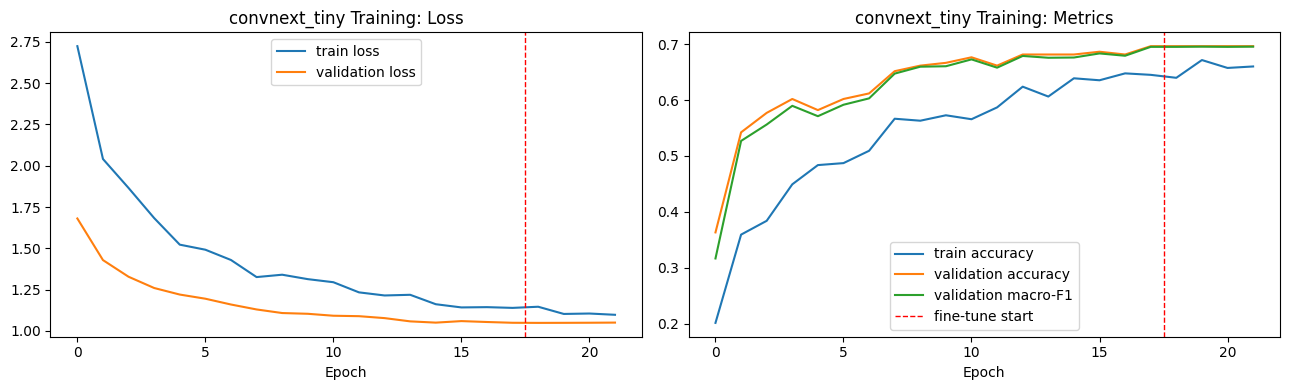

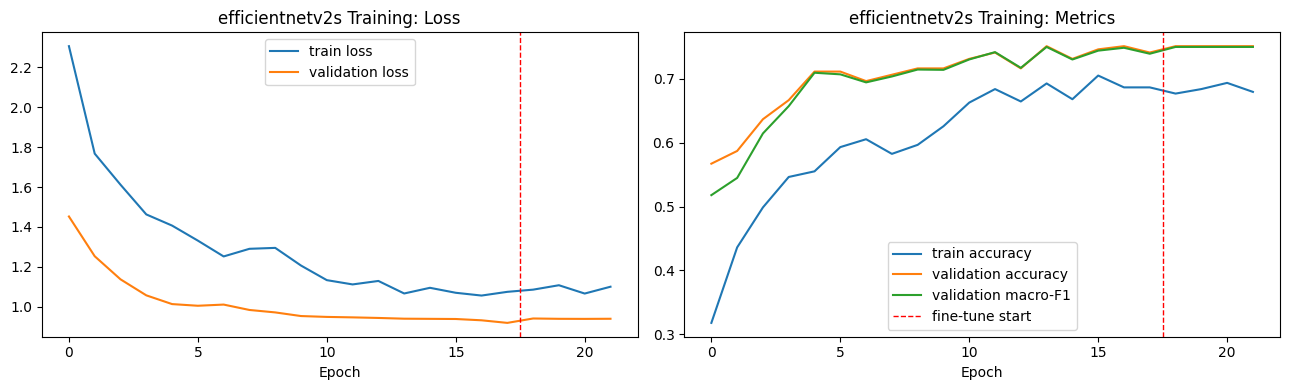

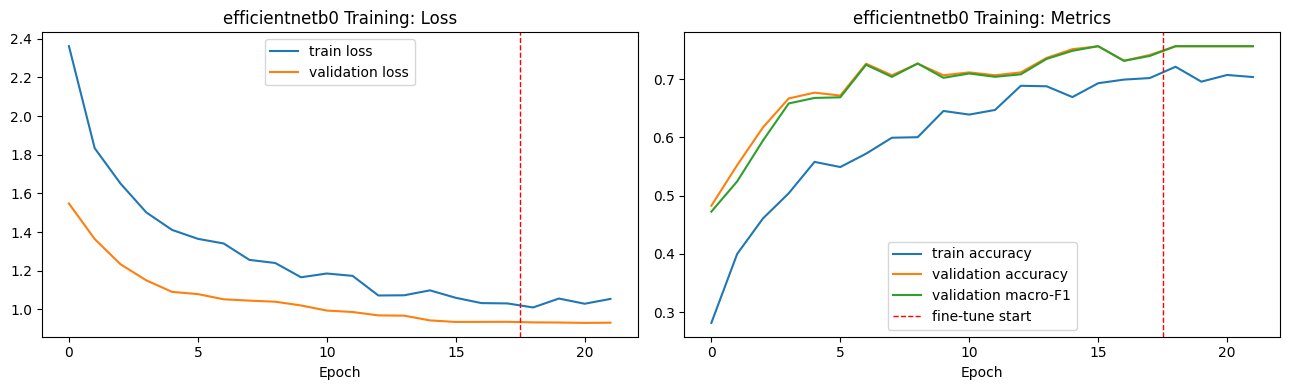

,strategy,accuracy,macro_f1,weighted_f1
0,efficientnetb0 flip-TTA softmax,0.751244,0.753102,0.754823
1,efficientnetv2s flip-TTA softmax,0.746269,0.744689,0.745329
2,convnext_tiny flip-TTA softmax,0.706468,0.704280,0.704185


[I 2026-05-08 11:37:51,116] A new study created in memory with name: no-name-2fdfcfd3-fc0b-4c03-85d2-cd026c147686


  0%|          | 0/900 [00:00<?, ?it/s]

[I 2026-05-08 11:37:51,133] Trial 0 finished with value: 0.7994270887528818 and parameters: {'w_convnext_tiny': 0.3745401188473625, 'w_efficientnetv2s': 0.9507143064099162, 'w_efficientnetb0': 0.7319939418114051}. Best is trial 0 with value: 0.7994270887528818.
[I 2026-05-08 11:37:51,138] Trial 1 finished with value: 0.7981298072768127 and parameters: {'w_convnext_tiny': 0.5986584841970366, 'w_efficientnetv2s': 0.15601864044243652, 'w_efficientnetb0': 0.15599452033620265}. Best is trial 0 with value: 0.7994270887528818.
[I 2026-05-08 11:37:51,144] Trial 2 finished with value: 0.7895477747167826 and parameters: {'w_convnext_tiny': 0.05808361216819946, 'w_efficientnetv2s': 0.8661761457749352, 'w_efficientnetb0': 0.6011150117432088}. Best is trial 0 with value: 0.7994270887528818.
[I 2026-05-08 11:37:51,151] Trial 3 finished with value: 0.7906162987308473 and parameters: {'w_convnext_tiny': 0.7080725777960455, 'w_efficientnetv2s': 0.020584494295802447, 'w_efficientnetb0': 0.96990985216199

,strategy,macro_f1,accuracy,weighted_f1,w_convnext_tiny,w_efficientnetv2s,w_efficientnetb0
0,optuna weighted ensemble,0.820685,0.820896,0.8215,0.273937,0.357514,0.368549
1,optuna weighted ensemble,0.820685,0.820896,0.8215,0.277813,0.345494,0.376692
2,optuna weighted ensemble,0.820685,0.820896,0.8215,0.284263,0.345771,0.369966
3,optuna weighted ensemble,0.820685,0.820896,0.8215,0.329491,0.346000,0.324509
4,optuna weighted ensemble,0.820685,0.820896,0.8215,0.315036,0.352620,0.332344
5,optuna weighted ensemble,0.820685,0.820896,0.8215,0.348025,0.362033,0.289943
6,optuna weighted ensemble,0.820685,0.820896,0.8215,0.305349,0.348327,0.346324
7,optuna weighted ensemble,0.820685,0.820896,0.8215,0.306627,0.354258,0.339115
8,optuna weighted ensemble,0.820685,0.820896,0.8215,0.314237,0.368733,0.317029
9,optuna weighted ensemble,0.820685,0.820896,0.8215,0.321039,0.344290,0.334671


...

pred,Brown_anole,Cuban_knight_anole,Green_anole
true,,,
Brown_anole,23,1,5
Cuban_knight_anole,1,0,1
Desert_iguana,1,0,0
Green_anole,10,1,16
Green_iguana,1,0,0
Lesser_Antillean_iguana,0,0,1


After brown/green calibration


pred,Brown_anole,Cuban_knight_anole,Green_anole
true,,,
Brown_anole,23,1,5
Cuban_knight_anole,1,0,1
Desert_iguana,1,0,0
Green_anole,10,1,16
Green_iguana,1,0,0
Lesser_Antillean_iguana,0,0,1


,strategy,accuracy,macro_f1,weighted_f1
0,optimized weighted ensemble,0.820896,0.820685,0.821500
1,efficientnetb0 flip-TTA softmax,0.751244,0.753102,0.754823
2,efficientnetv2s flip-TTA softmax,0.746269,0.744689,0.745329
3,convnext_tiny flip-TTA softmax,0.706468,0.704280,0.704185


                           precision    recall  f1-score   support

Black_spiny_tailed_iguana       0.93      0.87      0.90        30
              Brown_anole       0.64      0.79      0.71        29
       Cuban_knight_anole       0.90      0.93      0.91        28
            Desert_iguana       1.00      0.96      0.98        28
              Green_anole       0.70      0.59      0.64        27
             Green_iguana       0.88      0.73      0.80        30
  Lesser_Antillean_iguana       0.76      0.86      0.81        29

                 accuracy                           0.82       201
                macro avg       0.83      0.82      0.82       201
             weighted avg       0.83      0.82      0.82       201



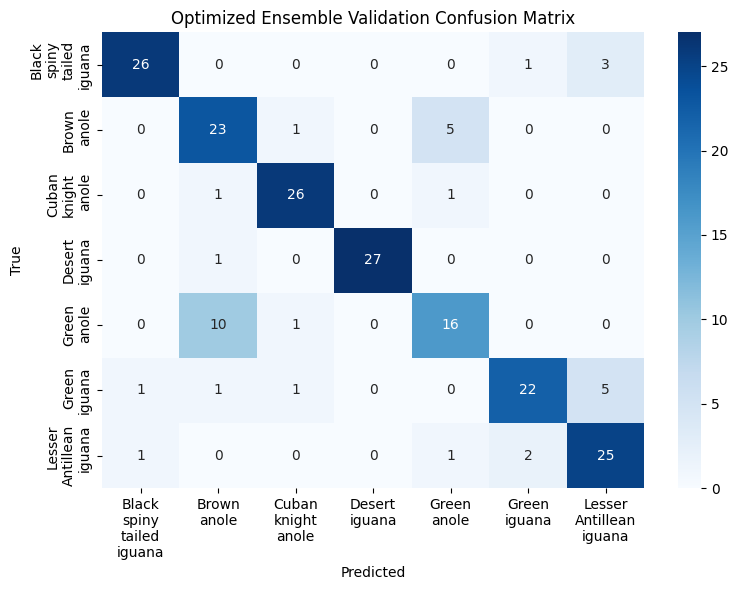

In [10]:
KNN_NEIGHBORS = [1, 3, 5, 7, 9, 11, 13, 15, 21, 31]
KNN_TEMPERATURES = [0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30]
BLEND_ALPHAS = np.linspace(0.0, 1.0, 51)


def plot_history(history_obj, title="Training History"):
    history_dict = history_obj.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_dict.get("loss", []), label="train")
    axes[0].plot(history_dict.get("val_loss", []), label="validation")
    axes[0].set_title(f"{title}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history_dict.get("accuracy", []), label="train accuracy")
    axes[1].plot(history_dict.get("val_accuracy", []), label="validation accuracy")
    if "val_macro_f1" in history_dict:
        axes[1].plot(history_dict["val_macro_f1"], label="validation macro-F1")
    axes[1].set_title(f"{title}: Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_combined_history(head_history, fine_tune_history=None, title="Final Model Training"):
    histories = [head_history.history]
    if fine_tune_history is not None:
        histories.append(fine_tune_history.history)

    def combine_metric(metric):
        combined = []
        for history in histories:
            combined.extend(history.get(metric, []))
        return combined

    fine_tune_start = len(histories[0].get("loss", []))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(combine_metric("loss"), label="train loss")
    axes[0].plot(combine_metric("val_loss"), label="validation loss")
    axes[0].set_title(f"{title}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(combine_metric("accuracy"), label="train accuracy")
    axes[1].plot(combine_metric("val_accuracy"), label="validation accuracy")
    val_macro_f1 = combine_metric("val_macro_f1")
    if val_macro_f1:
        axes[1].plot(val_macro_f1, label="validation macro-F1")
    axes[1].set_title(f"{title}: Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    if fine_tune_history is not None and fine_tune_start > 0:
        for axis in axes:
            axis.axvline(
                x=fine_tune_start - 0.5,
                color="red",
                linestyle="--",
                linewidth=1,
                label="fine-tune start",
            )
        handles, labels = axes[1].get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        axes[1].legend(unique.values(), unique.keys())

    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[name.replace("_", "\n") for name in class_names],
        yticklabels=[name.replace("_", "\n") for name in class_names],
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def _map_images_preserve_labels(dataset, image_fn):
    if isinstance(dataset.element_spec, tuple):
        return dataset.map(
            lambda images, labels: (image_fn(images), labels),
            num_parallel_calls=AUTOTUNE,
        ).prefetch(AUTOTUNE)
    return dataset.map(lambda images: image_fn(images), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


def horizontal_flip_dataset(dataset):
    return _map_images_preserve_labels(dataset, tf.image.flip_left_right)


def central_crop_dataset(dataset, central_fraction):
    central_fraction = float(central_fraction)
    if central_fraction >= 0.999:
        return dataset

    def crop_and_resize(images):
        cropped = tf.image.central_crop(images, central_fraction=central_fraction)
        return tf.image.resize(cropped, IMG_SIZE, method=tf.image.ResizeMethod.BICUBIC)

    return _map_images_preserve_labels(dataset, crop_and_resize)


def tta_datasets(dataset):
    if not USE_TTA:
        return [dataset]
    if not USE_ENHANCED_TTA:
        return [dataset, horizontal_flip_dataset(dataset)]
    variants = []
    seen = set()
    for fraction in TTA_CENTRAL_CROP_FRACTIONS:
        key = ("orig", float(fraction))
        if key not in seen:
            variants.append(central_crop_dataset(dataset, fraction))
            seen.add(key)
        key = ("flip", float(fraction))
        if key not in seen:
            variants.append(horizontal_flip_dataset(central_crop_dataset(dataset, fraction)))
            seen.add(key)
    return variants


def predict_softmax_tta(model, dataset):
    predictions = [model.predict(variant_ds, verbose=0) for variant_ds in tta_datasets(dataset)]
    return np.mean(predictions, axis=0)


def build_feature_extractor(model):
    try:
        embedding_output = model.get_layer("embedding_features").output
    except ValueError:
        embedding_output = model.layers[-2].output
    return keras.Model(model.input, embedding_output, name="embedding_extractor")


def extract_embeddings(feature_model, dataset):
    return feature_model.predict(dataset, verbose=0)


def l2_normalize(embeddings):
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    return embeddings / np.maximum(norms, 1e-8)


def compute_knn_probabilities(train_embeddings, train_labels, query_embeddings, k, temperature, num_classes):
    k = min(int(k), len(train_labels))
    similarities = query_embeddings @ train_embeddings.T
    top_idx = np.argpartition(-similarities, kth=k - 1, axis=1)[:, :k]
    top_similarities = np.take_along_axis(similarities, top_idx, axis=1)
    order = np.argsort(-top_similarities, axis=1)
    top_idx = np.take_along_axis(top_idx, order, axis=1)
    top_similarities = np.take_along_axis(top_similarities, order, axis=1)

    scaled = top_similarities / max(float(temperature), 1e-6)
    scaled = scaled - scaled.max(axis=1, keepdims=True)
    weights = np.exp(scaled)
    weights = weights / np.maximum(weights.sum(axis=1, keepdims=True), 1e-8)

    probabilities = np.zeros((len(query_embeddings), num_classes), dtype=np.float32)
    for row_idx in range(len(query_embeddings)):
        for neighbour_idx in range(k):
            label = int(train_labels[top_idx[row_idx, neighbour_idx]])
            probabilities[row_idx, label] += float(weights[row_idx, neighbour_idx])
    return probabilities


def metric_summary_from_probabilities(y_true, probabilities, name):
    predictions = probabilities.argmax(axis=1)
    return {
        "strategy": name,
        "accuracy": float(np.mean(predictions == y_true)),
        "macro_f1": float(f1_score(y_true, predictions, average="macro")),
        "weighted_f1": float(f1_score(y_true, predictions, average="weighted")),
    }


def search_inference_strategies(model, feature_model, train_eval_ds, train_labels, selection_ds, selection_labels):
    train_embeddings = l2_normalize(extract_embeddings(feature_model, train_eval_ds))
    selection_embeddings_orig = l2_normalize(extract_embeddings(feature_model, selection_ds))
    selection_embeddings_flip = l2_normalize(extract_embeddings(feature_model, horizontal_flip_dataset(selection_ds)))

    base_probabilities = model.predict(selection_ds, verbose=0)
    flip_probabilities = model.predict(horizontal_flip_dataset(selection_ds), verbose=0)
    tta_probabilities = (base_probabilities + flip_probabilities) / 2.0

    candidates = []

    def register(strategy_name, probabilities, metadata):
        summary = metric_summary_from_probabilities(selection_labels, probabilities, strategy_name)
        candidates.append({"strategy_name": strategy_name, "probabilities": probabilities, "metadata": metadata, **summary})

    register("single-pass softmax", base_probabilities, {"family": "softmax"})
    register("flip-TTA softmax", tta_probabilities, {"family": "softmax_tta"})

    embedding_variants = {
        "orig": selection_embeddings_orig,
        "flip_only": selection_embeddings_flip,
        "flip_avg": l2_normalize((selection_embeddings_orig + selection_embeddings_flip) / 2.0),
    }
    for embedding_variant, query_embeddings in embedding_variants.items():
        for temperature in KNN_TEMPERATURES:
            for k in KNN_NEIGHBORS:
                knn_probabilities = compute_knn_probabilities(
                    train_embeddings=train_embeddings,
                    train_labels=train_labels,
                    query_embeddings=query_embeddings,
                    k=k,
                    temperature=temperature,
                    num_classes=len(class_names),
                )
                register(
                    f"kNN only ({embedding_variant}, k={k}, temp={temperature:.2f})",
                    knn_probabilities,
                    {"family": "knn", "embedding_variant": embedding_variant, "k": k, "temperature": temperature},
                )
                for alpha in BLEND_ALPHAS:
                    blended_probabilities = alpha * tta_probabilities + (1.0 - alpha) * knn_probabilities
                    register(
                        f"blend TTA + kNN ({embedding_variant}, k={k}, temp={temperature:.2f}, alpha={alpha:.2f})",
                        blended_probabilities,
                        {
                            "family": "blend",
                            "embedding_variant": embedding_variant,
                            "k": k,
                            "temperature": temperature,
                            "alpha": float(alpha),
                        },
                    )

    results_df = (
        pd.DataFrame([
            {
                "strategy": candidate["strategy_name"],
                "accuracy": candidate["accuracy"],
                "macro_f1": candidate["macro_f1"],
                "weighted_f1": candidate["weighted_f1"],
            }
            for candidate in candidates
        ])
        .sort_values(["macro_f1", "accuracy"], ascending=False)
        .reset_index(drop=True)
    )
    best_candidate = max(candidates, key=lambda item: (item["macro_f1"], item["accuracy"]))
    assets = {"train_embeddings": train_embeddings, "train_labels": np.asarray(train_labels)}
    return results_df, best_candidate, assets


def predict_with_inference_strategy(model, feature_model, dataset, metadata, train_embeddings, train_labels):
    base_probabilities = model.predict(dataset, verbose=0)
    if metadata.get("family") == "softmax":
        return base_probabilities

    flip_probabilities = model.predict(horizontal_flip_dataset(dataset), verbose=0)
    tta_probabilities = (base_probabilities + flip_probabilities) / 2.0
    if metadata.get("family") == "softmax_tta":
        return tta_probabilities

    embeddings_orig = l2_normalize(extract_embeddings(feature_model, dataset))
    embeddings_flip = l2_normalize(extract_embeddings(feature_model, horizontal_flip_dataset(dataset)))
    embedding_variant = metadata.get("embedding_variant", "orig")
    if embedding_variant == "flip_only":
        query_embeddings = embeddings_flip
    elif embedding_variant == "flip_avg":
        query_embeddings = l2_normalize((embeddings_orig + embeddings_flip) / 2.0)
    else:
        query_embeddings = embeddings_orig

    knn_probabilities = compute_knn_probabilities(
        train_embeddings=train_embeddings,
        train_labels=train_labels,
        query_embeddings=query_embeddings,
        k=metadata["k"],
        temperature=metadata["temperature"],
        num_classes=len(class_names),
    )
    if metadata.get("family") == "knn":
        return knn_probabilities

    alpha = float(metadata["alpha"])
    return alpha * tta_probabilities + (1.0 - alpha) * knn_probabilities


for backbone_name, histories in training_histories.items():
    if histories["head"] is not None:
        plot_combined_history(
            histories["head"],
            histories["fine_tune"],
            title=f"{backbone_name} Training",
        )


def load_trained_model(backbone_name):
    model = keras.models.load_model(trained_model_paths[backbone_name], compile=False)
    model._backbone_name = backbone_name
    return model


def collect_backbone_probabilities(dataset):
    probabilities = {}
    for backbone_name in ACTIVE_ENSEMBLE_BACKBONES:
        model = load_trained_model(backbone_name)
        probabilities[backbone_name] = predict_softmax_tta(model, dataset)
        del model
        gc.collect()
        keras.backend.clear_session()
    return probabilities


def blend_probabilities(probabilities_by_backbone, weights):
    blended = None
    total_weight = 0.0
    for backbone_name in ACTIVE_ENSEMBLE_BACKBONES:
        weight = float(weights.get(backbone_name, 0.0))
        if weight <= 0:
            continue
        model_probabilities = probabilities_by_backbone[backbone_name]
        blended = model_probabilities * weight if blended is None else blended + model_probabilities * weight
        total_weight += weight
    if blended is None or total_weight <= 0:
        raise ValueError("At least one ensemble weight must be positive.")
    return blended / total_weight


def evaluate_ensemble_weights(probabilities_by_backbone, labels, weights, name="ensemble"):
    probabilities = blend_probabilities(probabilities_by_backbone, weights)
    summary = metric_summary_from_probabilities(labels, probabilities, name)
    return {**summary, **{f"w_{backbone_name}": float(weights.get(backbone_name, 0.0)) for backbone_name in ACTIVE_ENSEMBLE_BACKBONES}, "probabilities": probabilities}


def normalize_ensemble_weights(raw_weights):
    active_backbones = [
        backbone_name for backbone_name in ACTIVE_ENSEMBLE_BACKBONES
        if backbone_name in raw_weights
    ]
    if not active_backbones:
        active_backbones = list(raw_weights)
    total = sum(max(0.0, float(raw_weights.get(backbone_name, 0.0))) for backbone_name in active_backbones)
    if total <= 0:
        return {backbone_name: 1.0 / len(active_backbones) for backbone_name in active_backbones}
    return {
        backbone_name: max(0.0, float(raw_weights.get(backbone_name, 0.0))) / total
        for backbone_name in active_backbones
    }



def apply_pair_probability_calibration(probabilities, calibration):
    if not calibration or not calibration.get("enabled", False):
        return probabilities
    calibrated = np.asarray(probabilities, dtype=np.float32).copy()
    for class_id, multiplier in calibration.get("multipliers", {}).items():
        calibrated[:, int(class_id)] *= float(multiplier)
    calibrated = calibrated / np.maximum(calibrated.sum(axis=1, keepdims=True), 1e-8)
    return calibrated


def search_brown_green_pair_calibration(labels, probabilities):
    if not USE_BROWN_GREEN_PAIR_CALIBRATION or len(BROWN_GREEN_CLASS_IDS) < 2:
        return {"enabled": False, "reason": "brown/green pair not detected"}

    # Only calibrate the first detected brown and green classes.
    pair_ids = []
    for wanted in ["brown", "green"]:
        for class_id in BROWN_GREEN_CLASS_IDS:
            if wanted in class_names[class_id].lower():
                pair_ids.append(class_id)
                break
    pair_ids = sorted(set(pair_ids))
    if len(pair_ids) < 2:
        pair_ids = BROWN_GREEN_CLASS_IDS[:2]

    base_macro_f1 = float(f1_score(labels, probabilities.argmax(axis=1), average="macro"))
    best = {
        "enabled": True,
        "pair_ids": pair_ids,
        "pair_names": [class_names[i] for i in pair_ids],
        "multipliers": {int(pair_ids[0]): 1.0, int(pair_ids[1]): 1.0},
        "macro_f1": base_macro_f1,
        "improvement": 0.0,
    }

    for m0 in PAIR_CALIBRATION_GRID:
        for m1 in PAIR_CALIBRATION_GRID:
            candidate = {"enabled": True, "multipliers": {int(pair_ids[0]): float(m0), int(pair_ids[1]): float(m1)}}
            calibrated = apply_pair_probability_calibration(probabilities, candidate)
            macro_f1 = float(f1_score(labels, calibrated.argmax(axis=1), average="macro"))
            if macro_f1 > best["macro_f1"]:
                best.update({
                    "multipliers": candidate["multipliers"],
                    "macro_f1": macro_f1,
                    "improvement": macro_f1 - base_macro_f1,
                })
    return best


def brown_green_error_table(labels, probabilities, title="brown/green focus"):
    if len(BROWN_GREEN_CLASS_IDS) == 0:
        print("No brown/green classes detected.")
        return pd.DataFrame()
    predictions = probabilities.argmax(axis=1)
    mask = np.isin(labels, BROWN_GREEN_CLASS_IDS) | np.isin(predictions, BROWN_GREEN_CLASS_IDS)
    focus_df = pd.DataFrame({
        "true": [class_names[int(x)] for x in labels[mask]],
        "pred": [class_names[int(x)] for x in predictions[mask]],
    })
    table = pd.crosstab(focus_df["true"], focus_df["pred"], dropna=False)
    print(title)
    display(table)
    return table


def optuna_search_ensemble_weights(probabilities_by_backbone, labels, n_trials=300):
    trials = []

    def objective(trial):
        raw_weights = {
            backbone_name: trial.suggest_float(f"w_{backbone_name}", 0.0, 1.0)
            for backbone_name in ACTIVE_ENSEMBLE_BACKBONES
        }
        weights = normalize_ensemble_weights(raw_weights)
        probabilities = blend_probabilities(probabilities_by_backbone, weights)
        predictions = probabilities.argmax(axis=1)
        macro_f1 = float(f1_score(labels, predictions, average="macro"))
        accuracy = float(np.mean(predictions == labels))
        weighted_f1 = float(f1_score(labels, predictions, average="weighted"))
        trial.set_user_attr("weights", weights)
        trial.set_user_attr("accuracy", accuracy)
        trial.set_user_attr("weighted_f1", weighted_f1)
        trials.append(
            {
                "strategy": "optuna weighted ensemble",
                "macro_f1": macro_f1,
                "accuracy": accuracy,
                "weighted_f1": weighted_f1,
                **{f"w_{backbone_name}": weights[backbone_name] for backbone_name in ACTIVE_ENSEMBLE_BACKBONES},
            }
        )
        return macro_f1

    sampler = optuna.samplers.TPESampler(seed=SEED, multivariate=True)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=int(n_trials), show_progress_bar=True)
    results_df = pd.DataFrame(trials).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
    best_weights = dict(study.best_trial.user_attrs["weights"])
    return study, results_df, best_weights


val_probabilities_by_backbone = collect_backbone_probabilities(final_val_ds)

single_model_validation_table = pd.DataFrame([
    metric_summary_from_probabilities(final_val_labels, val_probabilities_by_backbone[backbone_name], f"{backbone_name} flip-TTA softmax")
    for backbone_name in ACTIVE_ENSEMBLE_BACKBONES
]).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
display(single_model_validation_table)

ensemble_weight_study, ensemble_results_df, selected_ensemble_weights = optuna_search_ensemble_weights(
    val_probabilities_by_backbone,
    final_val_labels,
    n_trials=ENSEMBLE_WEIGHT_OPTUNA_TRIALS,
)
ENSEMBLE_WEIGHTS.update(selected_ensemble_weights)

print(f"Best Optuna ensemble macro-F1: {ensemble_weight_study.best_value:.4f}")
print("Top Optuna ensemble weights:")
display(ensemble_results_df.head(10))
print("Optuna selected ensemble weights:", selected_ensemble_weights)

robust_candidate_rows = []
for candidate_name, candidate_weights in ENSEMBLE_ROBUST_CANDIDATE_WEIGHTS.items():
    weights = selected_ensemble_weights if candidate_weights is None else normalize_ensemble_weights(candidate_weights)
    summary = evaluate_ensemble_weights(
        val_probabilities_by_backbone,
        final_val_labels,
        weights,
        name=candidate_name,
    )
    summary.pop("probabilities", None)
    summary["min_weight"] = min(weights.get(backbone_name, 0.0) for backbone_name in ACTIVE_ENSEMBLE_BACKBONES)
    robust_candidate_rows.append(summary)

robust_candidate_results_df = pd.DataFrame(robust_candidate_rows).sort_values(
    ["macro_f1", "accuracy", "min_weight"],
    ascending=False,
).reset_index(drop=True)
display(robust_candidate_results_df)

optuna_macro_f1 = float(robust_candidate_results_df.loc[robust_candidate_results_df["strategy"] == "optuna", "macro_f1"].iloc[0])
if ENSEMBLE_SELECTION_MODE == "manual":
    selected_ensemble_weights = normalize_ensemble_weights(MANUAL_ENSEMBLE_WEIGHTS)
    selected_ensemble_strategy = "manual_optuna_weights"
    print("Using manual ensemble weights:", selected_ensemble_weights)
elif ENSEMBLE_SELECTION_MODE == "optuna":
    selected_ensemble_strategy = "optuna"
    print("Using raw Optuna ensemble weights.")
elif ENSEMBLE_SELECTION_MODE == "robust":
    robust_close_candidates = robust_candidate_results_df[
        (robust_candidate_results_df["strategy"] != "optuna")
        & (robust_candidate_results_df["macro_f1"] >= optuna_macro_f1 - ENSEMBLE_ROBUST_SELECTION_TOLERANCE)
    ].copy()
    if len(robust_close_candidates) > 0:
        chosen_row = robust_close_candidates.sort_values(
            ["macro_f1", "min_weight", "accuracy"],
            ascending=False,
        ).iloc[0]
        selected_ensemble_weights = {
            backbone_name: float(chosen_row[f"w_{backbone_name}"])
            for backbone_name in ACTIVE_ENSEMBLE_BACKBONES
        }
        selected_ensemble_strategy = str(chosen_row["strategy"])
        print(
            f"Using robust ensemble weights from {selected_ensemble_strategy}; "
            f"within {ENSEMBLE_ROBUST_SELECTION_TOLERANCE:.3f} macro-F1 of Optuna."
        )
    else:
        selected_ensemble_strategy = "optuna"
        print("Using Optuna ensemble weights; no robust candidate was close enough.")
else:
    raise ValueError(f"Unsupported ENSEMBLE_SELECTION_MODE: {ENSEMBLE_SELECTION_MODE}")
ENSEMBLE_WEIGHTS.update(selected_ensemble_weights)
print("Final selected ensemble strategy:", selected_ensemble_strategy)
print("Final selected ensemble weights:", selected_ensemble_weights)

final_val_probabilities_uncalibrated = blend_probabilities(val_probabilities_by_backbone, selected_ensemble_weights)
PAIR_CALIBRATION = search_brown_green_pair_calibration(final_val_labels, final_val_probabilities_uncalibrated)
print("Brown/green pair calibration:", PAIR_CALIBRATION)
final_val_probabilities = apply_pair_probability_calibration(final_val_probabilities_uncalibrated, PAIR_CALIBRATION)
final_val_predictions = final_val_probabilities.argmax(axis=1)

brown_green_error_table(final_val_labels, final_val_probabilities_uncalibrated, title="Before brown/green calibration")
brown_green_error_table(final_val_labels, final_val_probabilities, title="After brown/green calibration")

validation_metric_table = pd.concat(
    [
        single_model_validation_table,
        pd.DataFrame([
            metric_summary_from_probabilities(final_val_labels, final_val_probabilities, "optimized weighted ensemble")
        ]),
    ],
    ignore_index=True,
).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
display(validation_metric_table)

print(classification_report(final_val_labels, final_val_predictions, target_names=class_names))
plot_confusion(final_val_labels, final_val_predictions, title="Optimized Ensemble Validation Confusion Matrix")

In [11]:
# ─────────────────────────────────────────────────────────────
# SECTIE 3 — na de ensemble evaluatie (na plot_confusion(...))
# Plak dit blok direct na de validatie-resultaten cel
# =============================================================

def log_ensemble_results_to_wandb(
    val_labels,
    val_probabilities,
    class_names,
    selected_weights,
    selected_strategy,
    single_model_table,
    ensemble_results_df,
):
    """Logt ensemble metrics, confusion matrix en per-class F1 naar W&B."""
    with wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name="ensemble_evaluation",
        group="ensemble",
        reinit=True,
    ) as run:
        # ── Ensemble gewichten ───────────────────────────────────
        wandb.config.update({
            "ensemble_strategy": selected_strategy,
            "ensemble_weights": selected_weights,
        })

        # ── Validatie metrics ────────────────────────────────────
        val_predictions = val_probabilities.argmax(axis=1)
        val_accuracy = float(np.mean(val_predictions == val_labels))
        val_macro_f1 = float(f1_score(val_labels, val_predictions, average="macro"))
        val_weighted_f1 = float(f1_score(val_labels, val_predictions, average="weighted"))

        wandb.log({
            "ensemble/val_accuracy":    val_accuracy,
            "ensemble/val_macro_f1":    val_macro_f1,
            "ensemble/val_weighted_f1": val_weighted_f1,
        })
        wandb.summary["ensemble/val_macro_f1"]    = val_macro_f1
        wandb.summary["ensemble/val_accuracy"]    = val_accuracy
        wandb.summary["ensemble/val_weighted_f1"] = val_weighted_f1

        # ── Per-class F1 ─────────────────────────────────────────
        per_class_f1 = f1_score(val_labels, val_predictions, average=None)
        per_class_table = wandb.Table(
            columns=["class", "f1_score"],
            data=[[class_names[i], float(f1)] for i, f1 in enumerate(per_class_f1)],
        )
        wandb.log({"ensemble/per_class_f1_table": per_class_table})

        # Elk apart ook als scalar (handig voor parallel-coordinates plot in W&B)
        wandb.log({f"per_class_f1/{name}": float(f1)
                   for name, f1 in zip(class_names, per_class_f1)})

        # ── Confusion matrix ─────────────────────────────────────
        cm = confusion_matrix(val_labels, val_predictions,
                              labels=list(range(len(class_names))))
        wandb.log({
            "ensemble/confusion_matrix": wandb.plot.confusion_matrix(
                probs=None,
                y_true=val_labels.tolist(),
                preds=val_predictions.tolist(),
                class_names=class_names,
            )
        })

        # ── Single-model vergelijking als tabel ──────────────────
        single_model_wandb_table = wandb.Table(dataframe=single_model_table)
        wandb.log({"ensemble/single_model_comparison": single_model_wandb_table})

        # ── Optuna ensemble zoekresultaten ────────────────────────
        top_optuna = ensemble_results_df.head(20).copy()
        wandb.log({"ensemble/optuna_top20": wandb.Table(dataframe=top_optuna)})

        # ── Classificatie rapport als tekst ──────────────────────
        report = classification_report(
            val_labels, val_predictions, target_names=class_names
        )
        wandb.log({"ensemble/classification_report": wandb.Html(
            f"<pre>{report}</pre>"
        )})

        print("W&B ensemble results gelogd.")


# Aanroep — plak deze regel na ensemble evaluatie:
log_ensemble_results_to_wandb(
    val_labels=final_val_labels,
    val_probabilities=final_val_probabilities,
    class_names=class_names,
    selected_weights=selected_ensemble_weights,
    selected_strategy=selected_ensemble_strategy,
    single_model_table=single_model_validation_table,
    ensemble_results_df=ensemble_results_df,
)

W&B ensemble results gelogd.


ensemble/val_accuracy,▁
ensemble/val_macro_f1,▁
ensemble/val_weighted_f1,▁
per_class_f1/Black_spiny_tailed_iguana,▁
per_class_f1/Brown_anole,▁
per_class_f1/Cuban_knight_anole,▁
per_class_f1/Desert_iguana,▁
per_class_f1/Green_anole,▁
per_class_f1/Green_iguana,▁
per_class_f1/Lesser_Antillean_iguana,▁
ensemble/val_accuracy,0.8209


Brown/green specialist pair: Brown_anole vs Green_anole
Specialist train size: 315 validation size: 56


,train_count
binary_label,
Brown_anole,164
Green_anole,151


Training brown/green specialist head...
Epoch 1/16


E0000 00:00:1778240302.160775      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/lizard_efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.5535 - loss: 1.1119
Epoch 1: val_binary_score improved from -inf to 0.49173, saving model to /kaggle/working/best_brown_green_specialist.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 760ms/step - accuracy: 0.5545 - loss: 1.1146 - val_accuracy: 0.6607 - val_loss: 0.6399 - val_binary_f1: 0.6517 - val_binary_score: 0.4917 - learning_rate: 0.0010
Epoch 2/16
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.7364 - loss: 0.7439
Epoch 2: val_binary_score improved from 0.49173 to 0.53786, saving model to /kaggle/working/best_brown_green_specialist.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 378ms/step - accuracy: 0.7364 - loss: 0.7437 - val_accuracy: 0.7143 - val_loss: 0.6295 - val_binary_f1: 0.6952 - val_binary_score: 0.5379 - learning_rate: 0.0010
Epoch 3/16
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.7485 - loss: 0.7613
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00035000001662410796.

Epoch 3: val_binary_score did not improve

...

Selected brown/green specialist config: {'enabled': True, 'brown_id': 1, 'green_id': 4, 'brown_name': 'Brown_anole', 'green_name': 'Green_anole', 'path': '/kaggle/working/best_brown_green_specialist.keras', 'min_pair_mass': 1.01, 'blend': 0.0, 'top2_only': True, 'macro_f1': 0.8206849326151475, 'improvement': 0.0}
Before specialist: {'strategy': 'ensemble + calibration', 'accuracy': 0.8208955223880597, 'macro_f1': 0.8206849326151475, 'weighted_f1': 0.8214999709524393}
After specialist: {'strategy': 'ensemble + calibration + specialist', 'accuracy': 0.8208955223880597, 'macro_f1': 0.8206849326151475, 'weighted_f1': 0.8214999709524393}
Before brown/green specialist


pred,Brown_anole,Cuban_knight_anole,Green_anole
true,,,
Brown_anole,23,1,5
Cuban_knight_anole,1,0,1
Desert_iguana,1,0,0
Green_anole,10,1,16
Green_iguana,1,0,0
Lesser_Antillean_iguana,0,0,1


After brown/green specialist


pred,Brown_anole,Cuban_knight_anole,Green_anole
true,,,
Brown_anole,23,1,5
Cuban_knight_anole,1,0,1
Desert_iguana,1,0,0
Green_anole,10,1,16
Green_iguana,1,0,0
Lesser_Antillean_iguana,0,0,1


                           precision    recall  f1-score   support

Black_spiny_tailed_iguana       0.93      0.87      0.90        30
              Brown_anole       0.64      0.79      0.71        29
       Cuban_knight_anole       0.90      0.93      0.91        28
            Desert_iguana       1.00      0.96      0.98        28
              Green_anole       0.70      0.59      0.64        27
             Green_iguana       0.88      0.73      0.80        30
  Lesser_Antillean_iguana       0.76      0.86      0.81        29

                 accuracy                           0.82       201
                macro avg       0.83      0.82      0.82       201
             weighted avg       0.83      0.82      0.82       201



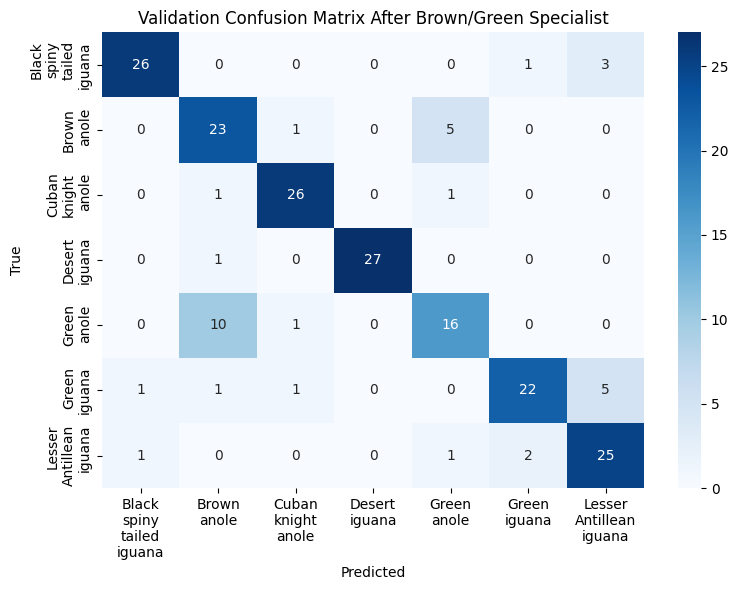

In [12]:

# Binary brown-vs-green specialist.
# This cell is intentionally placed AFTER the 7-class ensemble evaluation, because it uses
# final_val_probabilities as the baseline and searches a safe override rule on validation.

SPECIALIST_TRAINED = False
SPECIALIST_CONFIG = {"enabled": False, "reason": "not run"}
BROWN_GREEN_SPECIALIST_PATH = WORKING_ROOT / "best_brown_green_specialist.keras"


def get_brown_green_pair_ids():
    brown_ids = [i for i, name in enumerate(class_names) if "brown" in name.lower() and "anole" in name.lower()]
    green_ids = [i for i, name in enumerate(class_names) if "green" in name.lower() and "anole" in name.lower()]
    if not brown_ids or not green_ids:
        return None
    return int(brown_ids[0]), int(green_ids[0])


def make_binary_pair_dataframe(source_df, brown_id, green_id):
    pair_df = source_df[source_df["label"].isin([brown_id, green_id])].copy().reset_index(drop=True)
    # Binary order: column 0 = brown, column 1 = green.
    pair_df["binary_label"] = (pair_df["label"].astype(int) == int(green_id)).astype(int)
    return pair_df


def make_binary_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    paths = dataframe["filepath"].astype(str).values
    labels = dataframe["binary_label"].astype(np.int32).values
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    return dataset.map(decode_and_resize, num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)


def make_binary_class_weights(binary_labels):
    classes = np.array(sorted(pd.Series(binary_labels).unique()))
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=np.asarray(binary_labels))
    return {int(class_id): float(weight) for class_id, weight in zip(classes, weights)}


class BinaryValidationF1Callback(keras.callbacks.Callback):
    def __init__(self, validation_data, validation_labels):
        super().__init__()
        self.validation_data = validation_data
        self.validation_labels = np.asarray(validation_labels)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        probabilities = self.model.predict(self.validation_data, verbose=0)
        predictions = probabilities.argmax(axis=1)
        logs["val_binary_f1"] = float(f1_score(self.validation_labels, predictions, average="macro"))


def make_binary_specialist_callbacks(validation_ds, validation_labels, checkpoint_path, initial_lr, epochs, patience=4, phase="head"):
    class BinaryCompositeScoreCallback(keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            val_f1 = float(logs.get("val_binary_f1", 0.0))
            val_loss = float(logs.get("val_loss", 0.0))
            logs["val_binary_score"] = val_f1 - 0.25 * val_loss

    return [
        BinaryValidationF1Callback(validation_ds, validation_labels),
        BinaryCompositeScoreCallback(),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.35,
            patience=1,
            min_delta=0.002,
            min_lr=max(float(initial_lr) * 0.01, 1e-8),
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_binary_score",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=2 if phase == "fine_tune" else 3,
            min_delta=0.002,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_binary_score",
            mode="max",
            patience=patience,
            min_delta=0.001,
            restore_best_weights=True,
            verbose=1,
        ),
    ]


def train_brown_green_specialist():
    pair_ids = get_brown_green_pair_ids()
    if pair_ids is None:
        return None, {"enabled": False, "reason": "brown/green pair not detected"}

    brown_id, green_id = pair_ids
    bg_train_df = make_binary_pair_dataframe(train_df, brown_id, green_id)
    bg_val_df = make_binary_pair_dataframe(val_df, brown_id, green_id)

    if len(bg_train_df) < BROWN_GREEN_SPECIALIST_MIN_SAMPLES or len(bg_val_df) < 4:
        return None, {
            "enabled": False,
            "reason": "not enough brown/green train or validation samples",
            "train_samples": int(len(bg_train_df)),
            "val_samples": int(len(bg_val_df)),
        }

    print("Brown/green specialist pair:", class_names[brown_id], "vs", class_names[green_id])
    print("Specialist train size:", len(bg_train_df), "validation size:", len(bg_val_df))
    display(bg_train_df["binary_label"].value_counts().rename(index={0: class_names[brown_id], 1: class_names[green_id]}).to_frame("train_count"))

    bg_train_ds = make_binary_dataset(bg_train_df, batch_size=best_batch_size, shuffle=True)
    bg_val_ds = make_binary_dataset(bg_val_df, batch_size=best_batch_size, shuffle=False)
    bg_val_labels = bg_val_df["binary_label"].to_numpy(dtype=np.int64)
    bg_class_weights = make_binary_class_weights(bg_train_df["binary_label"].values)

    specialist = build_model(
        num_classes=2,
        dense_units=BROWN_GREEN_SPECIALIST_DENSE_UNITS,
        dropout_rate=BROWN_GREEN_SPECIALIST_DROPOUT,
        learning_rate=BROWN_GREEN_SPECIALIST_HEAD_LR,
        optimizer_name="adamw",
        weight_decay=BROWN_GREEN_SPECIALIST_WEIGHT_DECAY,
        backbone_name=BROWN_GREEN_SPECIALIST_BACKBONE,
    )

    print("Training brown/green specialist head...")
    head_history = specialist.fit(
        bg_train_ds,
        validation_data=bg_val_ds,
        epochs=BROWN_GREEN_SPECIALIST_HEAD_EPOCHS,
        callbacks=make_binary_specialist_callbacks(
            bg_val_ds,
            bg_val_labels,
            BROWN_GREEN_SPECIALIST_PATH,
            initial_lr=BROWN_GREEN_SPECIALIST_HEAD_LR,
            epochs=BROWN_GREEN_SPECIALIST_HEAD_EPOCHS,
            patience=5,
        ),
        class_weight=bg_class_weights,
        verbose=1,
    )

    set_backbone_fine_tuning(specialist, BROWN_GREEN_SPECIALIST_FINE_TUNE_LAST_N_LAYERS)
    compile_classifier_model(
        specialist,
        learning_rate=BROWN_GREEN_SPECIALIST_FINE_TUNE_LR,
        optimizer_name="adamw",
        weight_decay=BROWN_GREEN_SPECIALIST_WEIGHT_DECAY,
    )

    print("Fine-tuning brown/green specialist...")
    fine_history = specialist.fit(
        bg_train_ds,
        validation_data=bg_val_ds,
        epochs=BROWN_GREEN_SPECIALIST_FINE_TUNE_EPOCHS,
        callbacks=make_binary_specialist_callbacks(
            bg_val_ds,
            bg_val_labels,
            BROWN_GREEN_SPECIALIST_PATH,
            initial_lr=BROWN_GREEN_SPECIALIST_FINE_TUNE_LR,
            epochs=BROWN_GREEN_SPECIALIST_FINE_TUNE_EPOCHS,
            patience=5,
        ),
        class_weight=bg_class_weights,
        verbose=1,
    )

    if BROWN_GREEN_SPECIALIST_PATH.exists():
        specialist = keras.models.load_model(BROWN_GREEN_SPECIALIST_PATH, compile=False)
    else:
        specialist.save(BROWN_GREEN_SPECIALIST_PATH)

    bg_val_pred = specialist.predict(bg_val_ds, verbose=0).argmax(axis=1)
    print("Brown/green specialist validation report:")
    print(classification_report(bg_val_labels, bg_val_pred, target_names=[class_names[brown_id], class_names[green_id]]))

    config = {
        "enabled": True,
        "brown_id": int(brown_id),
        "green_id": int(green_id),
        "brown_name": class_names[brown_id],
        "green_name": class_names[green_id],
        "path": str(BROWN_GREEN_SPECIALIST_PATH),
    }
    return specialist, config


def predict_brown_green_specialist_probabilities(dataset):
    if not BROWN_GREEN_SPECIALIST_PATH.exists():
        raise FileNotFoundError(f"Missing brown/green specialist checkpoint: {BROWN_GREEN_SPECIALIST_PATH}")
    model = keras.models.load_model(BROWN_GREEN_SPECIALIST_PATH, compile=False)
    probabilities = predict_softmax_tta(model, dataset)
    del model
    gc.collect()
    keras.backend.clear_session()
    return probabilities


def apply_brown_green_specialist_to_probabilities(base_probabilities, specialist_pair_probabilities, config):
    if not config or not config.get("enabled", False):
        return base_probabilities

    brown_id = int(config["brown_id"])
    green_id = int(config["green_id"])
    min_pair_mass = float(config.get("min_pair_mass", 0.50))
    blend = float(config.get("blend", 1.00))
    top2_only = bool(config.get("top2_only", True))

    adjusted = np.asarray(base_probabilities, dtype=np.float32).copy()
    pair_mass = adjusted[:, brown_id] + adjusted[:, green_id]
    base_pair = adjusted[:, [brown_id, green_id]] / np.maximum(pair_mass[:, None], 1e-8)
    specialist_pair = np.asarray(specialist_pair_probabilities, dtype=np.float32)
    mixed_pair = (1.0 - blend) * base_pair + blend * specialist_pair

    top2 = np.argsort(-adjusted, axis=1)[:, :2]
    pair_in_top2 = np.isin(top2, [brown_id, green_id]).sum(axis=1) == 2
    mask = pair_mass >= min_pair_mass
    if top2_only:
        mask = mask & pair_in_top2

    adjusted[mask, brown_id] = pair_mass[mask] * mixed_pair[mask, 0]
    adjusted[mask, green_id] = pair_mass[mask] * mixed_pair[mask, 1]
    adjusted = adjusted / np.maximum(adjusted.sum(axis=1, keepdims=True), 1e-8)
    return adjusted


def search_specialist_override_config(labels, base_probabilities, specialist_pair_probabilities, config):
    if not config or not config.get("enabled", False):
        return config, base_probabilities

    baseline_f1 = float(f1_score(labels, base_probabilities.argmax(axis=1), average="macro"))
    best_config = dict(config)
    best_config.update({"min_pair_mass": 1.01, "blend": 0.0, "top2_only": True, "macro_f1": baseline_f1, "improvement": 0.0})
    best_probabilities = base_probabilities

    rows = []
    for top2_only in SPECIALIST_TOP2_ONLY_OPTIONS:
        for min_pair_mass in SPECIALIST_MIN_PAIR_MASS_GRID:
            for blend in SPECIALIST_BLEND_GRID:
                candidate_config = dict(config)
                candidate_config.update({
                    "min_pair_mass": float(min_pair_mass),
                    "blend": float(blend),
                    "top2_only": bool(top2_only),
                })
                candidate_probabilities = apply_brown_green_specialist_to_probabilities(
                    base_probabilities,
                    specialist_pair_probabilities,
                    candidate_config,
                )
                macro_f1 = float(f1_score(labels, candidate_probabilities.argmax(axis=1), average="macro"))
                accuracy = float(np.mean(candidate_probabilities.argmax(axis=1) == labels))
                rows.append({
                    "macro_f1": macro_f1,
                    "accuracy": accuracy,
                    "min_pair_mass": float(min_pair_mass),
                    "blend": float(blend),
                    "top2_only": bool(top2_only),
                })
                if macro_f1 > best_config["macro_f1"]:
                    best_config.update({
                        "min_pair_mass": float(min_pair_mass),
                        "blend": float(blend),
                        "top2_only": bool(top2_only),
                        "macro_f1": macro_f1,
                        "improvement": macro_f1 - baseline_f1,
                    })
                    best_probabilities = candidate_probabilities

    search_df = pd.DataFrame(rows).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
    print("Top specialist override settings:")
    display(search_df.head(10))
    return best_config, best_probabilities


if USE_BROWN_GREEN_SPECIALIST:
    specialist_model, SPECIALIST_CONFIG = train_brown_green_specialist()
    if SPECIALIST_CONFIG.get("enabled", False):
        SPECIALIST_TRAINED = True
        val_specialist_pair_probabilities = predict_softmax_tta(specialist_model, final_val_ds)
        del specialist_model
        gc.collect()
        keras.backend.clear_session()

        SPECIALIST_CONFIG, final_val_probabilities_with_specialist = search_specialist_override_config(
            final_val_labels,
            final_val_probabilities,
            val_specialist_pair_probabilities,
            SPECIALIST_CONFIG,
        )

        print("Selected brown/green specialist config:", SPECIALIST_CONFIG)
        print("Before specialist:", metric_summary_from_probabilities(final_val_labels, final_val_probabilities, "ensemble + calibration"))
        print("After specialist:", metric_summary_from_probabilities(final_val_labels, final_val_probabilities_with_specialist, "ensemble + calibration + specialist"))
        brown_green_error_table(final_val_labels, final_val_probabilities, title="Before brown/green specialist")
        brown_green_error_table(final_val_labels, final_val_probabilities_with_specialist, title="After brown/green specialist")

        # From here onward, use the specialist-enhanced validation probabilities.
        final_val_probabilities = final_val_probabilities_with_specialist
        final_val_predictions = final_val_probabilities.argmax(axis=1)
        print(classification_report(final_val_labels, final_val_predictions, target_names=class_names))
        plot_confusion(final_val_labels, final_val_predictions, title="Validation Confusion Matrix After Brown/Green Specialist")
    else:
        print("Brown/green specialist skipped:", SPECIALIST_CONFIG)
else:
    print("Brown/green specialist disabled.")


Saved hard validation CSV: /kaggle/working/hard_validation_examples/hard_validation_examples.csv


,id,true_name,pred_name,confidence,true_probability,margin,filepath
0,Green_iguana_Green_iguana_195.jpg,Green_iguana,Lesser_Antillean_iguana,0.717222,0.242087,0.475135,/kaggle/input/competitions/lizard-prediction-t...
1,Brown_anole_Brown_anole_180.jpg,Brown_anole,Green_anole,0.676148,0.161471,0.514677,/kaggle/input/competitions/lizard-prediction-t...
2,Green_anole_Green_anole_27.jpg,Green_anole,Brown_anole,0.670300,0.252512,0.417788,/kaggle/input/competitions/lizard-prediction-t...
3,Green_anole_Green_anole_16.jpg,Green_anole,Brown_anole,0.670179,0.238125,0.432054,/kaggle/input/competitions/lizard-prediction-t...
4,Green_anole_Green_anole_183.jpg,Green_anole,Brown_anole,0.661764,0.290889,0.370875,/kaggle/input/competitions/lizard-prediction-t...
5,Green_anole_Green_anole_159.jpg,Green_anole,Brown_anole,0.649884,0.265999,0.383884,/kaggle/input/competitions/lizard-prediction-t...
6,Brown_anole_Anolis_carolinensis_12.jpg,Brown_anole,Green_anole,0.647239,0.226849,0.420390,/kaggle/input/competitions/lizard-prediction-t...
7,Brown_anole_Brown_anole_177.jpg,Brown_anole,Green_anole,0.640887,0.213223,0.427664,/kaggle/input/competitions/lizard-prediction-t...
8,Green_anole_Green_anole_73.jpg,Green_anole,Brown_anole,0.580167,0.320469,0.259697,/kaggle/input/competitions/lizard-prediction-t...
9,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,Green_iguana,0.578603,0.156198,0.336436,/kaggle/input/competitions/lizard-prediction-t...


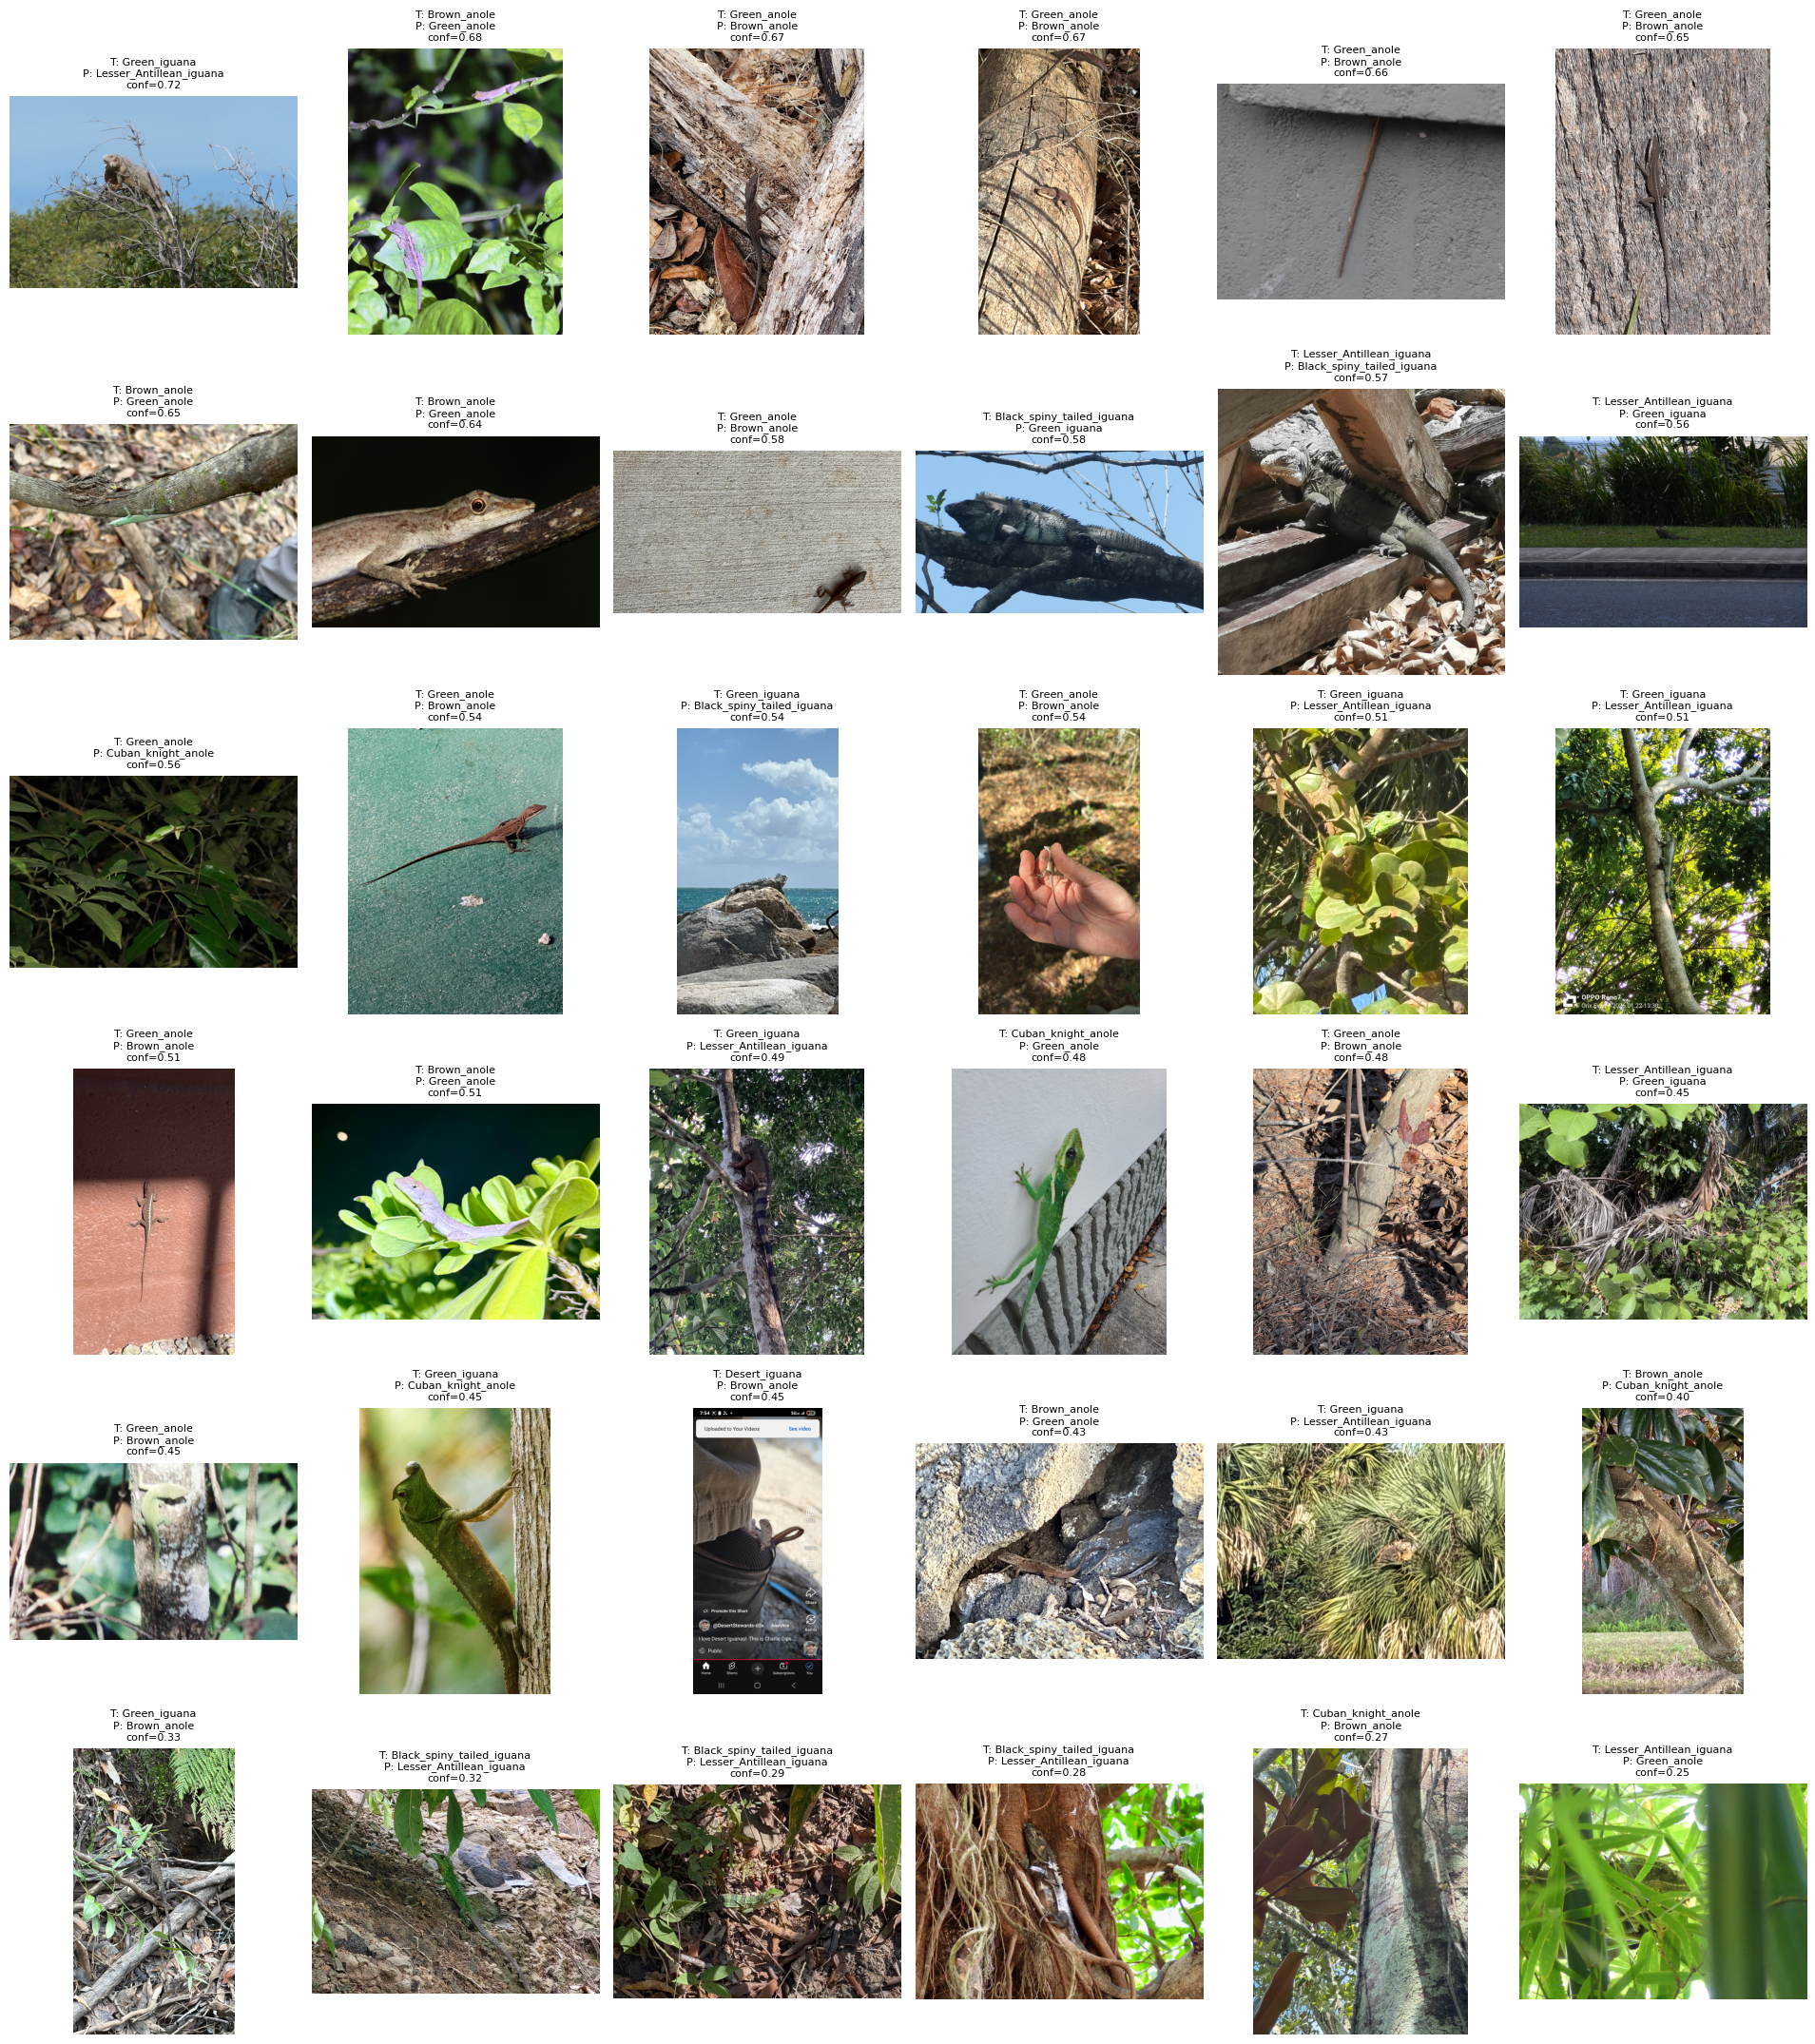

Saved contact sheet: /kaggle/working/hard_validation_examples/confident_wrong_contact_sheet.png


In [13]:

# Export hardest validation examples for manual inspection.
# Very useful when score stalls: often the ceiling is caused by mislabeled images, duplicates, screenshots or impossible cases.

if EXPORT_HARD_VALIDATION_EXAMPLES:
    hard_dir = Path(WORKING_ROOT) / "hard_validation_examples"
    hard_dir.mkdir(parents=True, exist_ok=True)
    val_debug = val_df.copy().reset_index(drop=True)
    val_debug["true_name"] = val_debug["label"].map(id_to_class)
    val_debug["pred"] = final_val_probabilities.argmax(axis=1)
    val_debug["pred_name"] = val_debug["pred"].map(id_to_class)
    val_debug["confidence"] = final_val_probabilities.max(axis=1)
    val_debug["true_probability"] = [final_val_probabilities[i, int(label)] for i, label in enumerate(val_debug["label"].values)]
    val_debug["margin"] = np.sort(final_val_probabilities, axis=1)[:, -1] - np.sort(final_val_probabilities, axis=1)[:, -2]
    val_debug["is_wrong"] = val_debug["label"].astype(int) != val_debug["pred"].astype(int)
    val_debug = val_debug.sort_values(["is_wrong", "confidence"], ascending=[False, False]).reset_index(drop=True)

    csv_path = hard_dir / "hard_validation_examples.csv"
    val_debug.to_csv(csv_path, index=False)
    print("Saved hard validation CSV:", csv_path)
    display(val_debug.head(25)[["id", "true_name", "pred_name", "confidence", "true_probability", "margin", "filepath"]])

    # Create a compact contact sheet of the most confident wrong predictions.
    wrong_df = val_debug[val_debug["is_wrong"]].head(36)
    if len(wrong_df) > 0:
        cols = 6
        rows = int(np.ceil(len(wrong_df) / cols))
        plt.figure(figsize=(cols * 3.2, rows * 3.6))
        for i, (_, row) in enumerate(wrong_df.iterrows()):
            try:
                img = plt.imread(row["filepath"])
                plt.subplot(rows, cols, i + 1)
                plt.imshow(img)
                plt.axis("off")
                plt.title(f"T: {row['true_name']}\nP: {row['pred_name']}\nconf={row['confidence']:.2f}", fontsize=8)
            except Exception as exc:
                print("Could not read", row["filepath"], exc)
        plt.tight_layout()
        sheet_path = hard_dir / "confident_wrong_contact_sheet.png"
        plt.savefig(sheet_path, dpi=160, bbox_inches="tight")
        plt.show()
        print("Saved contact sheet:", sheet_path)
    else:
        print("No wrong validation predictions found.")
else:
    print("Hard validation export disabled.")


In [14]:
# ─────────────────────────────────────────────────────────────
# SECTIE 4 — na het harde-voorbeelden blok (EXPORT_HARD_VALIDATION_EXAMPLES)
# Logt de moeilijkste voorspellingen als visuele W&B tabel
# =============================================================

def log_hard_examples_to_wandb(val_debug_df, val_probabilities, class_names, top_n=50):
    """
    Logt de top-N meest-confidently-wrong validatiebeelden als
    een W&B table met inline afbeeldingen.
    """
    with wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name="hard_validation_examples",
        group="diagnostics",
        reinit=True,
    ) as run:
        wrong_df = val_debug_df[val_debug_df["is_wrong"]].head(top_n).reset_index(drop=True)

        columns = ["image", "true_label", "pred_label",
                   "confidence", "true_probability", "margin"]
        table_data = []

        for _, row in wrong_df.iterrows():
            try:
                img = wandb.Image(
                    str(row["filepath"]),
                    caption=(
                        f"True: {row['true_name']} | "
                        f"Pred: {row['pred_name']} | "
                        f"conf={row['confidence']:.2f}"
                    ),
                )
                table_data.append([
                    img,
                    row["true_name"],
                    row["pred_name"],
                    round(float(row["confidence"]), 4),
                    round(float(row["true_probability"]), 4),
                    round(float(row["margin"]), 4),
                ])
            except Exception as exc:
                print(f"Kon {row['filepath']} niet laden: {exc}")

        table = wandb.Table(columns=columns, data=table_data)
        wandb.log({"diagnostics/hard_validation_examples": table})

        # Samenvatting
        wandb.summary["diagnostics/n_wrong_predictions"] = int(val_debug_df["is_wrong"].sum())
        wandb.summary["diagnostics/accuracy_on_val"] = float(
            (~val_debug_df["is_wrong"]).mean()
        )
        print(f"W&B: {len(table_data)} harde voorbeelden gelogd.")


# Aanroep — plak dit direct na het EXPORT_HARD_VALIDATION_EXAMPLES blok:
if EXPORT_HARD_VALIDATION_EXAMPLES and "val_debug" in dir():
    log_hard_examples_to_wandb(val_debug, final_val_probabilities, class_names)

W&B: 36 harde voorbeelden gelogd.


diagnostics/accuracy_on_val,0.8209
diagnostics/n_wrong_predictions,36


In [15]:
import shutil
import json

# Maak expliciet de 3 aparte Keras-modellen én één gecombineerd Keras ensemble-model.
# Run deze cel nadat de final training + Optuna ensemble selectie klaar zijn.

CREATE_EXPLICIT_KERAS_MODELS = True
SAVE_EXPLICIT_KERAS_MODELS = True

if CREATE_EXPLICIT_KERAS_MODELS:
    if "trained_model_paths" not in globals() or not trained_model_paths:
        raise NameError("trained_model_paths bestaat nog niet. Run eerst de final training cell.")
    if "selected_ensemble_weights" not in globals():
        raise NameError("selected_ensemble_weights bestaat nog niet. Run eerst de ensemble/Optuna evaluation cell.")

    @keras.utils.register_keras_serializable(package="Lizard")
    class HorizontalFlip(layers.Layer):
        def call(self, inputs):
            return tf.image.flip_left_right(inputs)

    @keras.utils.register_keras_serializable(package="Lizard")
    class WeightedProbabilityEnsemble(layers.Layer):
        def __init__(self, weights, **kwargs):
            super().__init__(**kwargs)
            self.ensemble_weights = [float(weight) for weight in weights]

        def call(self, inputs):
            if len(inputs) != len(self.ensemble_weights):
                raise ValueError("The number of probability tensors must match the number of weights.")
            total_weight = float(sum(self.ensemble_weights))
            if total_weight <= 0:
                raise ValueError("At least one ensemble weight must be positive.")

            blended = tf.zeros_like(tf.cast(inputs[0], tf.float32))
            for probability_tensor, weight in zip(inputs, self.ensemble_weights):
                blended = blended + tf.cast(probability_tensor, tf.float32) * tf.cast(weight, tf.float32)
            return blended / tf.cast(total_weight, tf.float32)

        def get_config(self):
            config = super().get_config()
            config.update({"weights": self.ensemble_weights})
            return config

    @keras.utils.register_keras_serializable(package="Lizard")
    class AverageProbabilities(layers.Layer):
        def call(self, inputs):
            if len(inputs) != 2:
                raise ValueError("AverageProbabilities expects exactly two tensors.")
            return (tf.cast(inputs[0], tf.float32) + tf.cast(inputs[1], tf.float32)) / 2.0

    def load_standalone_keras_model(backbone_name):
        if backbone_name not in trained_model_paths:
            raise KeyError(f"Geen checkpoint gevonden voor {backbone_name}. Beschikbaar: {list(trained_model_paths)}")
        model_path = Path(trained_model_paths[backbone_name])
        if not model_path.exists():
            raise FileNotFoundError(f"Checkpoint bestaat niet: {model_path}")

        model = keras.models.load_model(model_path, compile=False)
        model.trainable = False
        for layer in model.layers:
            layer.trainable = False
        try:
            model._name = f"{backbone_name}_standalone_keras_model"
        except Exception:
            pass
        return model

    # 1) De drie aparte Keras-modellen als echte variabelen.
    keras_backbone_models = {
        backbone_name: load_standalone_keras_model(backbone_name)
        for backbone_name in ACTIVE_ENSEMBLE_BACKBONES
    }

    # Handige losse variabelen, zodat je ze apart kan gebruiken in Kaggle.
    convnext_tiny_model = keras_backbone_models.get("convnext_tiny")
    efficientnetv2s_model = keras_backbone_models.get("efficientnetv2s")
    efficientnetb0_model = keras_backbone_models.get("efficientnetb0")

    # 2) De drie aparte modellen ook opslaan met duidelijke namen.
    exported_keras_model_paths = {}
    if SAVE_EXPLICIT_KERAS_MODELS:
        for backbone_name, model in keras_backbone_models.items():
            export_path = Path(WORKING_ROOT) / f"lizard_{backbone_name}_standalone.keras"
            artifact_export_path = Path(ARTIFACTS_DIR) / f"lizard_{backbone_name}_standalone.keras"
            model.save(export_path)
            model.save(artifact_export_path)
            exported_keras_model_paths[backbone_name] = export_path

    # 3) Eén gecombineerd Keras ensemble-model maken.
    # Dit model doet zelf:
    # input image -> 3 aparte modellen -> weighted average -> horizontal flip -> opnieuw -> gemiddelde.
    ensemble_weights_for_model = normalize_ensemble_weights(
        {backbone_name: float(selected_ensemble_weights.get(backbone_name, 0.0)) for backbone_name in ACTIVE_ENSEMBLE_BACKBONES}
    )

    ensemble_input = keras.Input(shape=(*IMG_SIZE, 3), name="image")

    normal_probabilities = []
    flipped_probabilities = []
    flipped_input = HorizontalFlip(name="flip_tta_horizontal_flip")(ensemble_input)

    for backbone_name in ACTIVE_ENSEMBLE_BACKBONES:
        submodel = keras_backbone_models[backbone_name]

        normal_probs = submodel(ensemble_input, training=False)
        normal_probs = layers.Activation(
            "linear",
            dtype="float32",
            name=f"normal_{backbone_name}_probabilities_float32",
        )(normal_probs)
        normal_probabilities.append(normal_probs)

        flip_probs = submodel(flipped_input, training=False)
        flip_probs = layers.Activation(
            "linear",
            dtype="float32",
            name=f"flipped_{backbone_name}_probabilities_float32",
        )(flip_probs)
        flipped_probabilities.append(flip_probs)

    normal_ensemble = WeightedProbabilityEnsemble(
        [ensemble_weights_for_model[backbone_name] for backbone_name in ACTIVE_ENSEMBLE_BACKBONES],
        name="normal_weighted_probability_ensemble",
    )(normal_probabilities)

    flipped_ensemble = WeightedProbabilityEnsemble(
        [ensemble_weights_for_model[backbone_name] for backbone_name in ACTIVE_ENSEMBLE_BACKBONES],
        name="flipped_weighted_probability_ensemble",
    )(flipped_probabilities)

    ensemble_output = AverageProbabilities(name="flip_tta_probability_average")(
        [normal_ensemble, flipped_ensemble]
    )

    combined_ensemble_model = keras.Model(
        ensemble_input,
        ensemble_output,
        name="lizard_3_backbone_weighted_ensemble_flip_tta",
    )

    combined_ensemble_model_path = Path(WORKING_ROOT) / "lizard_3_backbone_weighted_ensemble_flip_tta.keras"
    combined_ensemble_model_artifact_path = Path(ARTIFACTS_DIR) / "lizard_3_backbone_weighted_ensemble_flip_tta.keras"
    if SAVE_EXPLICIT_KERAS_MODELS:
        combined_ensemble_model.save(combined_ensemble_model_path)
        combined_ensemble_model.save(combined_ensemble_model_artifact_path)

    print("Aparte Keras-modellen aangemaakt:")
    for backbone_name, model in keras_backbone_models.items():
        print(f"- {backbone_name}: {model.name}")
        if backbone_name in exported_keras_model_paths:
            print(f"  saved to: {exported_keras_model_paths[backbone_name]}")

    print("\nGecombineerd ensemble-model aangemaakt:")
    print("- variable: combined_ensemble_model")
    print("- name:", combined_ensemble_model.name)
    print("- weights:", ensemble_weights_for_model)
    if SAVE_EXPLICIT_KERAS_MODELS:
        print("- saved to:", combined_ensemble_model_path)

    # Snelle sanity check: outputvorm moet (batch_size, aantal klassen) zijn.
    combined_ensemble_model.summary()


# 4) Maak de artifacts expliciet zichtbaar in /kaggle/working/artifacts én bundel alles in één zip.
# In Kaggle verschijnen deze pas nadat de cel effectief is uitgevoerd.
try:
    artifact_rows = []
    for backbone_name, root_path in exported_keras_model_paths.items():
        artifact_path = Path(ARTIFACTS_DIR) / f"lizard_{backbone_name}_standalone.keras"
        artifact_rows.append({
            "artifact": f"{backbone_name}_standalone",
            "path": str(artifact_path),
            "exists": artifact_path.exists(),
            "size_mb": round(artifact_path.stat().st_size / (1024 ** 2), 2) if artifact_path.exists() and artifact_path.is_file() else None,
        })

    combined_artifact_path = Path(ARTIFACTS_DIR) / "lizard_3_backbone_weighted_ensemble_flip_tta.keras"
    if "combined_ensemble_model" in globals() and combined_artifact_path.exists() is False:
        combined_ensemble_model.save(combined_artifact_path)

    artifact_rows.append({
        "artifact": "combined_ensemble_model",
        "path": str(combined_artifact_path),
        "exists": combined_artifact_path.exists(),
        "size_mb": round(combined_artifact_path.stat().st_size / (1024 ** 2), 2) if combined_artifact_path.exists() and combined_artifact_path.is_file() else None,
    })

    manifest = {
        "standalone_models": {name: str(Path(ARTIFACTS_DIR) / f"lizard_{name}_standalone.keras") for name in keras_backbone_models.keys()},
        "combined_ensemble_model": str(combined_artifact_path),
        "selected_ensemble_weights": {str(k): float(v) for k, v in selected_ensemble_weights.items()},
        "img_size": list(IMG_SIZE),
        "class_names": list(class_names),
    }
    manifest_path = Path(ARTIFACTS_DIR) / "artifacts_manifest.json"
    with open(manifest_path, "w", encoding="utf-8") as file:
        json.dump(manifest, file, indent=2)

    artifact_table = pd.DataFrame(artifact_rows)
    artifact_table_path = Path(ARTIFACTS_DIR) / "artifacts_manifest.csv"
    artifact_table.to_csv(artifact_table_path, index=False)

    zip_base = Path(WORKING_ROOT) / "lizard_keras_artifacts"
    zip_path = shutil.make_archive(str(zip_base), "zip", ARTIFACTS_DIR)

    print("\nKeras artifacts saved. Check these in the Kaggle Output panel after running this cell:")
    display(artifact_table)
    print("Artifacts folder:", ARTIFACTS_DIR)
    print("Artifacts zip:", zip_path)
except Exception as artifact_exc:
    print("Artifact export failed:", artifact_exc)


# Extra zichtbaarheid in Kaggle Output: toon exact wat in /kaggle/working staat.
try:
    print("\nFiles directly under /kaggle/working:")
    for p in sorted(Path(WORKING_ROOT).glob("lizard*")):
        kind = "DIR" if p.is_dir() else "FILE"
        size = ""
        if p.is_file():
            size = f" - {p.stat().st_size / (1024**2):.2f} MB"
        print(f"- {kind}: {p}{size}")
    print("\nFiles under artifacts:")
    for p in sorted(Path(ARTIFACTS_DIR).glob("*")):
        kind = "DIR" if p.is_dir() else "FILE"
        size = ""
        if p.is_file():
            size = f" - {p.stat().st_size / (1024**2):.2f} MB"
        print(f"- {kind}: {p}{size}")
except Exception as listing_exc:
    print("Could not list artifact files:", listing_exc)

Aparte Keras-modellen aangemaakt:
- convnext_tiny: lizard_convnext_tiny
  saved to: /kaggle/working/lizard_convnext_tiny_standalone.keras
- efficientnetv2s: lizard_efficientnetv2s
  saved to: /kaggle/working/lizard_efficientnetv2s_standalone.keras
- efficientnetb0: lizard_efficientnetb0
  saved to: /kaggle/working/lizard_efficientnetb0_standalone.keras

Gecombineerd ensemble-model aangemaakt:
- variable: combined_ensemble_model
- name: lizard_3_backbone_weighted_ensemble_flip_tta
- weights: {'convnext_tiny': 0.2739374838559167, 'efficientnetv2s': 0.3575135996520722, 'efficientnetb0': 0.36854891649201116}
- saved to: /kaggle/working/lizard_3_backbone_weighted_ensemble_flip_tta.keras


Model: "lizard_3_backbone_weighted_ensemble_flip_tta"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 448, 448,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flip_tta_horizonta… │ (None, 448, 448,  │          0 │ image[0][0]       │
│ (HorizontalFlip)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lizard_convnext_ti… │ (None, 7)         │ 27,848,167 │ image[0][0],      │
│ (Functional)        │                   │            │ flip_tta_horizon… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lizard_efficientne… │ (None, 7)         │ 20,377,831 │ image[0][0],      │
│ (Functional)        │                   │            │ flip_tta_horizon… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lizard_efficientne… │ (None, 7)         │  4,096,042 │ image[0][0],      │
│ (Functional)        │                   │            │ flip_tta_horizon… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normal_convnext_ti… │ (None, 7)         │          0 │ lizard_convnext_… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normal_efficientne… │ (None, 7)         │          0 │ lizard_efficient… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normal_efficientne… │ (None, 7)         │          0 │ lizard_efficient… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flipped_convnext_t… │ (None, 7)         │          0 │ lizard_convnext_… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flipped_efficientn… │ (None, 7)         │          0 │ lizard_efficient… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flipped_efficientn… │ (None, 7)         │          0 │ lizard_efficient… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normal_weighted_pr… │ (None, 7)         │          0 │ normal_convnext_… │
│ (WeightedProbabili… │                   │            │ normal_efficient… │
│                     │                   │            │ normal_efficient… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flipped_weighted_p… │ (None, 7)         │          0 │ flipped_convnext… │
│ (WeightedProbabili… │                   │            │ flipped_efficien… │
│                     │                   │            │ flipped_efficien… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flip_tta_probabili… │ (None, 7)         │          0 │ normal_weighted_… │
│ (AverageProbabilit… │                   │            │ flipped_weighted… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 52,322,040 (199.59 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 52,322,040 (199.59 MB)


Keras artifacts saved. Check these in the Kaggle Output panel after running this cell:


,artifact,path,exists,size_mb
0,convnext_tiny_standalone,/kaggle/working/artifacts/lizard_convnext_tiny...,True,106.76
1,efficientnetv2s_standalone,/kaggle/working/artifacts/lizard_efficientnetv...,True,79.46
2,efficientnetb0_standalone,/kaggle/working/artifacts/lizard_efficientnetb...,True,16.46
3,combined_ensemble_model,/kaggle/working/artifacts/lizard_3_backbone_we...,True,202.70


Artifacts folder: /kaggle/working/artifacts
Artifacts zip: /kaggle/working/lizard_keras_artifacts.zip

Files directly under /kaggle/working:
- FILE: /kaggle/working/lizard_3_backbone_weighted_ensemble_flip_tta.keras - 202.70 MB
- FILE: /kaggle/working/lizard_convnext_tiny_standalone.keras - 106.76 MB
- FILE: /kaggle/working/lizard_efficientnetb0_standalone.keras - 16.46 MB
- FILE: /kaggle/working/lizard_efficientnetv2s_standalone.keras - 79.46 MB
- FILE: /kaggle/working/lizard_keras_artifacts.zip - 370.40 MB

Files under artifacts:
- FILE: /kaggle/working/artifacts/artifacts_manifest.csv - 0.00 MB
- FILE: /kaggle/working/artifacts/artifacts_manifest.json - 0.00 MB
- FILE: /kaggle/working/artifacts/lizard_3_backbone_weighted_ensemble_flip_tta.keras - 202.70 MB
- FILE: /kaggle/working/artifacts/lizard_convnext_tiny_standalone.keras - 106.76 MB
- FILE: /kaggle/working/artifacts/lizard_efficientnetb0_standalone.keras - 16.46 MB
- FILE: /kaggle/working/artifacts/lizard_efficientnetv2s_stand

In [16]:
def predict_weighted_ensemble(dataset, model_paths=None, weights=None):
    model_paths = model_paths or trained_model_paths
    weights = weights or selected_ensemble_weights
    missing = [backbone_name for backbone_name in ACTIVE_ENSEMBLE_BACKBONES if backbone_name not in model_paths]
    if missing:
        raise ValueError(f"Missing ensemble checkpoints for: {missing}")

    probabilities = None
    total_weight = 0.0
    for backbone_name in ACTIVE_ENSEMBLE_BACKBONES:
        model_path = Path(model_paths[backbone_name])
        if not model_path.exists():
            raise FileNotFoundError(f"Checkpoint for {backbone_name} not found at {model_path}")

        ensemble_model = keras.models.load_model(model_path, compile=False)
        weight = float(weights.get(backbone_name, 0.0))
        model_probabilities = predict_softmax_tta(ensemble_model, dataset)
        probabilities = model_probabilities * weight if probabilities is None else probabilities + model_probabilities * weight
        total_weight += weight
        print(f"Added {backbone_name} to ensemble with weight {weight:.3f}.")
        del ensemble_model
        gc.collect()
        keras.backend.clear_session()

    if probabilities is None or total_weight <= 0:
        raise ValueError("No positive ensemble weights were found.")
    return probabilities / total_weight


test_ds = make_inference_dataset(test_df, batch_size=best_batch_size)

test_probabilities_uncalibrated = predict_weighted_ensemble(test_ds)
test_probabilities = apply_pair_probability_calibration(test_probabilities_uncalibrated, globals().get("PAIR_CALIBRATION", None))

if globals().get("SPECIALIST_TRAINED", False) and globals().get("SPECIALIST_CONFIG", {}).get("enabled", False):
    test_specialist_pair_probabilities = predict_brown_green_specialist_probabilities(test_ds)
    test_probabilities = apply_brown_green_specialist_to_probabilities(
        test_probabilities,
        test_specialist_pair_probabilities,
        SPECIALIST_CONFIG,
    )
    print("Applied brown/green specialist to submission probabilities.")

print("Submission inference strategy: optimized weighted backbone ensemble + enhanced TTA + brown/green calibration + optional brown/green specialist")
print("Submission ensemble strategy:", selected_ensemble_strategy)
print("Submission ensemble weights:", selected_ensemble_weights)

submission = test_df[["id"]].copy()
submission["label"] = test_probabilities.argmax(axis=1).astype(int)

submission_path = WORKING_ROOT / "submission.csv"
submission.to_csv(submission_path, index=False)

print("Saved submission to:", submission_path)
print(submission.head())

Added convnext_tiny to ensemble with weight 0.274.
Added efficientnetv2s to ensemble with weight 0.358.
Added efficientnetb0 to ensemble with weight 0.369.
Applied brown/green specialist to submission probabilities.
Submission inference strategy: optimized weighted backbone ensemble + enhanced TTA + brown/green calibration + optional brown/green specialist
Submission ensemble strategy: optuna
Submission ensemble weights: {'convnext_tiny': 0.2739374838559167, 'efficientnetv2s': 0.3575135996520722, 'efficientnetb0': 0.36854891649201116}
Saved submission to: /kaggle/working/submission.csv
   id  label
0   1      6
1   2      5
2   3      2
3   4      5
4   5      0


In [17]:
# ─────────────────────────────────────────────────────────────
# SECTIE 5 — na de submission cel
# Logt de submission verdeling en afsluitende samenvatting
# =============================================================

def log_submission_summary_to_wandb(submission_df, test_probabilities, class_names,
                                    selected_weights, selected_strategy):
    """Logt de label-verdeling van de submission en model-configuratie."""
    with wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name="submission_summary",
        group="submission",
        reinit=True,
    ) as run:
        # Label verdeling
        label_counts = submission_df["label"].map(
            {i: name for i, name in enumerate(class_names)}
        ).value_counts()

        dist_table = wandb.Table(
            columns=["class", "count"],
            data=[[cls, int(cnt)] for cls, cnt in label_counts.items()],
        )
        wandb.log({"submission/label_distribution": dist_table})

        # Gemiddelde voorspellingszekerheden per klasse
        mean_conf_per_class = {
            class_names[i]: float(test_probabilities[:, i].mean())
            for i in range(len(class_names))
        }
        wandb.log({f"submission/mean_prob_{k}": v for k, v in mean_conf_per_class.items()})

        # Ensemble configuratie
        wandb.config.update({
            "final_ensemble_strategy": selected_strategy,
            "final_ensemble_weights":  selected_weights,
            "n_test_samples":          len(submission_df),
        })

        wandb.summary["submission/n_test_samples"] = len(submission_df)
        print("W&B submission summary gelogd.")


# Aanroep — plak dit na de submission.to_csv(...) regel:
log_submission_summary_to_wandb(
    submission_df=submission,
    test_probabilities=test_probabilities,
    class_names=class_names,
    selected_weights=selected_ensemble_weights,
    selected_strategy=selected_ensemble_strategy,
)

W&B submission summary gelogd.


submission/mean_prob_Black_spiny_tailed_iguana,▁
submission/mean_prob_Brown_anole,▁
submission/mean_prob_Cuban_knight_anole,▁
submission/mean_prob_Desert_iguana,▁
submission/mean_prob_Green_anole,▁
submission/mean_prob_Green_iguana,▁
submission/mean_prob_Lesser_Antillean_iguana,▁
submission/mean_prob_Black_spiny_tailed_iguana,0.12901
submission/mean_prob_Brown_anole,0.1402
submission/mean_prob_Cuban_knight_anole,0.12824
submission/mean_prob_Desert_iguana,0.1617


In [18]:
# Optional combined ensemble export + Cleanlab-ready Brown/Green review exports.
# This cell does not retrain or overwrite the three separate backbone checkpoints.

import json
from pathlib import Path

CREATE_COMBINED_ENSEMBLE_MODEL = False  # already created in section 6C
EXPORT_CLEANLAB_REVIEW_FILES = True

REPORT_DIR = Path(globals().get("REPORT_DIR", Path(WORKING_ROOT) / "reports"))
REPORT_DIR.mkdir(parents=True, exist_ok=True)


def _normalised_id_to_class():
    if "id_to_class" in globals():
        return {int(class_id): str(class_name) for class_id, class_name in id_to_class.items()}
    if "class_to_id" in globals():
        return {int(class_id): str(class_name) for class_name, class_id in class_to_id.items()}
    if "class_names" in globals():
        return {int(class_id): str(class_name) for class_id, class_name in enumerate(class_names)}
    raise NameError("Could not find id_to_class, class_to_id, or class_names for Cleanlab export.")


id_to_class = _normalised_id_to_class()
class_to_id = {class_name: class_id for class_id, class_name in id_to_class.items()}
class_names_for_export = [id_to_class[class_id] for class_id in sorted(id_to_class)]


if CREATE_COMBINED_ENSEMBLE_MODEL:
    @keras.utils.register_keras_serializable(package="Lizard")
    class HorizontalFlip(layers.Layer):
        def call(self, inputs):
            return tf.image.flip_left_right(inputs)


    @keras.utils.register_keras_serializable(package="Lizard")
    class WeightedProbabilityEnsemble(layers.Layer):
        def __init__(self, weights, **kwargs):
            super().__init__(**kwargs)
            self.ensemble_weights = [float(weight) for weight in weights]

        def call(self, inputs):
            if len(inputs) != len(self.ensemble_weights):
                raise ValueError("The number of probability tensors must match the number of weights.")
            total_weight = float(sum(self.ensemble_weights))
            if total_weight <= 0:
                raise ValueError("At least one ensemble weight must be positive.")

            blended = tf.zeros_like(tf.cast(inputs[0], tf.float32))
            for probability_tensor, weight in zip(inputs, self.ensemble_weights):
                blended = blended + tf.cast(probability_tensor, tf.float32) * tf.cast(weight, tf.float32)
            return blended / tf.cast(total_weight, tf.float32)

        def get_config(self):
            config = super().get_config()
            config.update({"weights": self.ensemble_weights})
            return config


    @keras.utils.register_keras_serializable(package="Lizard")
    class AverageProbabilities(layers.Layer):
        def call(self, inputs):
            if len(inputs) != 2:
                raise ValueError("AverageProbabilities expects exactly two tensors.")
            return (tf.cast(inputs[0], tf.float32) + tf.cast(inputs[1], tf.float32)) / 2.0


    def _load_frozen_submodel(backbone_name):
        if backbone_name not in trained_model_paths:
            raise KeyError(f"Missing checkpoint path for {backbone_name} in trained_model_paths.")
        model_path = Path(trained_model_paths[backbone_name])
        if not model_path.exists():
            raise FileNotFoundError(f"Checkpoint for {backbone_name} not found at {model_path}")

        submodel = keras.models.load_model(model_path, compile=False)
        submodel.trainable = False
        for layer in submodel.layers:
            layer.trainable = False
        try:
            submodel._name = f"ensemble_submodel_{backbone_name}"
        except Exception:
            pass
        return submodel


    def _weighted_ensemble_branch(images, submodels, weights, branch_name):
        branch_probabilities = []
        for backbone_name in ACTIVE_ENSEMBLE_BACKBONES:
            probabilities = submodels[backbone_name](images, training=False)
            probabilities = layers.Activation(
                "linear",
                dtype="float32",
                name=f"{branch_name}_{backbone_name}_probabilities_float32",
            )(probabilities)
            branch_probabilities.append(probabilities)
        return WeightedProbabilityEnsemble(
            [weights[backbone_name] for backbone_name in ACTIVE_ENSEMBLE_BACKBONES],
            name=f"{branch_name}_weighted_probability_ensemble",
        )(branch_probabilities)


    print("Selected ensemble weights:", selected_ensemble_weights)

    ensemble_weights_for_model = normalize_ensemble_weights(
        {backbone_name: float(selected_ensemble_weights.get(backbone_name, 0.0)) for backbone_name in ACTIVE_ENSEMBLE_BACKBONES}
    )
    ensemble_submodels = {
        backbone_name: _load_frozen_submodel(backbone_name)
        for backbone_name in ACTIVE_ENSEMBLE_BACKBONES
    }

    ensemble_input = keras.Input(shape=(*IMG_SIZE, 3), name="image")
    normal_probabilities = _weighted_ensemble_branch(
        ensemble_input,
        ensemble_submodels,
        ensemble_weights_for_model,
        branch_name="normal",
    )
    flipped_input = HorizontalFlip(name="flip_tta_horizontal_flip")(ensemble_input)
    flipped_probabilities = _weighted_ensemble_branch(
        flipped_input,
        ensemble_submodels,
        ensemble_weights_for_model,
        branch_name="flipped",
    )
    ensemble_output = AverageProbabilities(name="flip_tta_probability_average")(
        [normal_probabilities, flipped_probabilities]
    )

    combined_ensemble_model = keras.Model(
        ensemble_input,
        ensemble_output,
        name="lizard_weighted_ensemble_flip_tta",
    )
    combined_model_path = Path(WORKING_ROOT) / "lizard_weighted_ensemble_flip_tta.keras"
    combined_ensemble_model.save(combined_model_path)

    reloaded_combined_model = keras.models.load_model(
        combined_model_path,
        compile=False,
        custom_objects={
            "HorizontalFlip": HorizontalFlip,
            "WeightedProbabilityEnsemble": WeightedProbabilityEnsemble,
            "AverageProbabilities": AverageProbabilities,
        },
    )

    if "final_val_probabilities" in globals():
        reference_val_probabilities = np.asarray(final_val_probabilities, dtype=np.float32)
    else:
        reference_val_probabilities = blend_probabilities(
            collect_backbone_probabilities(final_val_ds),
            selected_ensemble_weights,
        ).astype(np.float32)

    combined_val_probabilities = reloaded_combined_model.predict(final_val_ds, verbose=0).astype(np.float32)
    prediction_differences = np.abs(reference_val_probabilities - combined_val_probabilities)
    identical_class_percentage = 100.0 * np.mean(
        reference_val_probabilities.argmax(axis=1) == combined_val_probabilities.argmax(axis=1)
    )

    print("Saved combined model path:", combined_model_path)
    print(f"Combined model file size: {combined_model_path.stat().st_size / (1024 ** 2):.2f} MB")
    print(f"Max absolute prediction difference: {prediction_differences.max():.8f}")
    print(f"Mean absolute prediction difference: {prediction_differences.mean():.8f}")
    print(f"Identical predicted classes: {identical_class_percentage:.2f}%")


if EXPORT_CLEANLAB_REVIEW_FILES:
    exported_paths = []

    if "final_holdout_probabilities" in globals() and "final_y_true" in globals():
        pred_probs = np.asarray(final_holdout_probabilities, dtype=np.float32)
        y_true = np.asarray(final_y_true, dtype=np.int64)
        cleanlab_source_name = "holdout"
    elif "final_val_probabilities" in globals() and "final_val_labels" in globals():
        pred_probs = np.asarray(final_val_probabilities, dtype=np.float32)
        y_true = np.asarray(final_val_labels, dtype=np.int64)
        cleanlab_source_name = "validation"
    elif "final_val_labels" in globals():
        pred_probs = blend_probabilities(
            collect_backbone_probabilities(final_val_ds),
            selected_ensemble_weights,
        ).astype(np.float32)
        y_true = np.asarray(final_val_labels, dtype=np.int64)
        cleanlab_source_name = "validation"
    else:
        raise NameError("Could not find final holdout or validation probabilities/labels for Cleanlab export.")

    if len(pred_probs) != len(y_true):
        raise ValueError(f"pred_probs length ({len(pred_probs)}) does not match y_true length ({len(y_true)}).")

    def _matching_results_dataframe(source_name, labels):
        if "final_results_df" in globals() and len(final_results_df) == len(labels):
            return final_results_df.copy()

        candidate_names = []
        if source_name == "holdout":
            candidate_names.extend(["holdout_test_df", "holdout_df", "final_holdout_df", "val_df"])
        else:
            candidate_names.extend(["val_df", "final_val_df", "validation_df", "holdout_test_df"])

        for candidate_name in candidate_names:
            candidate = globals().get(candidate_name)
            if isinstance(candidate, pd.DataFrame) and len(candidate) == len(labels) and "filepath" in candidate.columns:
                return candidate.copy()
        raise NameError("Could not find a matching dataframe with filepath values for Cleanlab export.")

    results_df = _matching_results_dataframe(cleanlab_source_name, y_true).reset_index(drop=True)
    results_df["filepath"] = results_df["filepath"].astype(str)
    results_df["label"] = y_true.astype(int)
    results_df["label_name"] = results_df["label"].map(id_to_class)
    results_df["_cleanlab_row_id"] = np.arange(len(results_df), dtype=np.int64)

    pred_labels = pred_probs.argmax(axis=1).astype(np.int64)
    pred_confidence = pred_probs[np.arange(len(pred_probs)), pred_labels]
    true_label_probability = pred_probs[np.arange(len(pred_probs)), y_true]

    brown_class_name = "Brown_anole"
    green_class_name = "Green_anole"
    missing_target_classes = [name for name in [brown_class_name, green_class_name] if name not in class_to_id]
    if missing_target_classes:
        raise KeyError(f"Missing Brown/Green target classes in class mapping: {missing_target_classes}")

    brown_id = int(class_to_id[brown_class_name])
    green_id = int(class_to_id[green_class_name])
    target_class_ids = {brown_id, green_id}
    target_class_names = {brown_class_name, green_class_name}

    cleanlab_pred_probs_path = REPORT_DIR / "cleanlab_pred_probs.npy"
    cleanlab_true_labels_path = REPORT_DIR / "cleanlab_true_labels.npy"
    cleanlab_class_names_path = REPORT_DIR / "cleanlab_class_names.json"
    cleanlab_review_predictions_path = REPORT_DIR / "cleanlab_review_predictions.csv"
    cleanlab_label_issues_path = REPORT_DIR / "cleanlab_label_issues.csv"
    cleanlab_brown_green_review_path = REPORT_DIR / "cleanlab_brown_green_anole_review.csv"

    np.save(cleanlab_pred_probs_path, pred_probs)
    np.save(cleanlab_true_labels_path, y_true)
    with open(cleanlab_class_names_path, "w", encoding="utf-8") as file:
        json.dump(class_names_for_export, file, indent=2)
    exported_paths.extend([cleanlab_pred_probs_path, cleanlab_true_labels_path, cleanlab_class_names_path])

    review_predictions = pd.DataFrame(
        {
            "_cleanlab_row_id": results_df["_cleanlab_row_id"].values,
            "filepath": results_df["filepath"].values,
            "filename": results_df["filepath"].map(lambda path: Path(path).name).values,
            "true_label_id": y_true.astype(int),
            "true_label_name": [id_to_class[int(label)] for label in y_true],
            "predicted_label_id": pred_labels.astype(int),
            "predicted_label_name": [id_to_class[int(label)] for label in pred_labels],
            "predicted_confidence": pred_confidence,
            "true_label_probability": true_label_probability,
            "brown_anole_probability": pred_probs[:, brown_id],
            "green_anole_probability": pred_probs[:, green_id],
        }
    )
    review_predictions["brown_green_probability_gap"] = (
        review_predictions["brown_anole_probability"] - review_predictions["green_anole_probability"]
    )
    review_predictions["brown_green_probability_sum"] = (
        review_predictions["brown_anole_probability"] + review_predictions["green_anole_probability"]
    )
    review_predictions["is_brown_or_green_true_label"] = review_predictions["true_label_id"].isin(target_class_ids)
    review_predictions["is_brown_or_green_predicted_label"] = review_predictions["predicted_label_id"].isin(target_class_ids)
    review_predictions["brown_green_confusion"] = (
        ((review_predictions["true_label_id"] == brown_id) & (review_predictions["predicted_label_id"] == green_id))
        | ((review_predictions["true_label_id"] == green_id) & (review_predictions["predicted_label_id"] == brown_id))
    )
    review_predictions["correct"] = review_predictions["true_label_id"] == review_predictions["predicted_label_id"]

    review_prediction_columns = [
        "filepath",
        "filename",
        "true_label_id",
        "true_label_name",
        "predicted_label_id",
        "predicted_label_name",
        "predicted_confidence",
        "true_label_probability",
        "brown_anole_probability",
        "green_anole_probability",
        "brown_green_probability_gap",
        "is_brown_or_green_true_label",
        "is_brown_or_green_predicted_label",
        "brown_green_confusion",
        "correct",
    ]
    review_predictions[review_prediction_columns].to_csv(cleanlab_review_predictions_path, index=False)
    exported_paths.append(cleanlab_review_predictions_path)

    cleanlab_enrichment = None
    try:
        from cleanlab.filter import find_label_issues

        label_issue_indices = find_label_issues(
            labels=y_true,
            pred_probs=pred_probs,
            return_indices_ranked_by="self_confidence",
        )

        issue_probabilities = pred_probs[label_issue_indices]
        issue_true_labels = y_true[label_issue_indices]
        issue_pred_labels = issue_probabilities.argmax(axis=1)
        issue_true_confidence = issue_probabilities[np.arange(len(issue_probabilities)), issue_true_labels]
        issue_pred_confidence = issue_probabilities[np.arange(len(issue_probabilities)), issue_pred_labels]

        cleanlab_issues = results_df.iloc[label_issue_indices].copy().reset_index(drop=True)
        cleanlab_issues["cleanlab_rank"] = np.arange(1, len(cleanlab_issues) + 1)
        cleanlab_issues["current_label"] = cleanlab_issues["label_name"]
        cleanlab_issues["suggested_label"] = [id_to_class[int(label)] for label in issue_pred_labels]
        cleanlab_issues["current_label_probability"] = issue_true_confidence
        cleanlab_issues["suggested_label_probability"] = issue_pred_confidence
        cleanlab_issues["issue_score"] = 1.0 - cleanlab_issues["current_label_probability"]
        cleanlab_issues["filename"] = cleanlab_issues["filepath"].apply(lambda path: Path(path).name)
        cleanlab_issues["needs_review"] = cleanlab_issues["current_label"] != cleanlab_issues["suggested_label"]
        cleanlab_issues = cleanlab_issues.sort_values(
            ["needs_review", "issue_score"],
            ascending=[False, False],
        )
        cleanlab_enrichment = cleanlab_issues[
            [
                "_cleanlab_row_id",
                "cleanlab_rank",
                "suggested_label",
                "suggested_label_probability",
                "issue_score",
                "needs_review",
            ]
        ].copy()
        cleanlab_issues = cleanlab_issues[
            [
                "cleanlab_rank",
                "filename",
                "filepath",
                "current_label",
                "suggested_label",
                "current_label_probability",
                "suggested_label_probability",
                "issue_score",
                "needs_review",
            ]
        ]
        cleanlab_issues.to_csv(cleanlab_label_issues_path, index=False)
        exported_paths.append(cleanlab_label_issues_path)
        print(f"Potential label issues found: {len(cleanlab_issues)}")
    except ImportError:
        print("Cleanlab is not installed. Exported probabilities, labels, and Brown/Green review files only.")

    brown_green_source_df = review_predictions.copy()
    if cleanlab_enrichment is not None:
        brown_green_source_df = brown_green_source_df.merge(
            cleanlab_enrichment,
            on="_cleanlab_row_id",
            how="left",
        )
        cleanlab_suggests_brown_or_green = brown_green_source_df["suggested_label"].isin(target_class_names)
    else:
        cleanlab_suggests_brown_or_green = pd.Series(False, index=brown_green_source_df.index)

    brown_green_focus_mask = (
        brown_green_source_df["true_label_id"].isin(target_class_ids)
        | brown_green_source_df["predicted_label_id"].isin(target_class_ids)
        | cleanlab_suggests_brown_or_green
    )
    brown_green_review = brown_green_source_df.loc[brown_green_focus_mask].copy()

    def _review_reason(row):
        if row["true_label_id"] == brown_id and row["predicted_label_id"] == green_id:
            return "true_brown_pred_green"
        if row["true_label_id"] == green_id and row["predicted_label_id"] == brown_id:
            return "true_green_pred_brown"
        if row["true_label_id"] in target_class_ids:
            return "true_brown_or_green"
        if row["predicted_label_id"] in target_class_ids:
            return "pred_brown_or_green"
        if "suggested_label" in row.index and row.get("suggested_label") in target_class_names:
            return "cleanlab_suggests_brown_or_green"
        return "brown_green_review"

    brown_green_review["review_reason"] = brown_green_review.apply(_review_reason, axis=1)
    brown_green_review["_absolute_brown_green_probability_gap"] = brown_green_review[
        "brown_green_probability_gap"
    ].abs()
    brown_green_review = brown_green_review.sort_values(
        [
            "brown_green_confusion",
            "predicted_confidence",
            "true_label_probability",
            "_absolute_brown_green_probability_gap",
        ],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)

    brown_green_review_columns = [
        "filepath",
        "filename",
        "true_label_id",
        "true_label_name",
        "predicted_label_id",
        "predicted_label_name",
        "predicted_confidence",
        "true_label_probability",
        "brown_anole_probability",
        "green_anole_probability",
        "brown_green_probability_gap",
        "brown_green_probability_sum",
        "brown_green_confusion",
        "correct",
        "review_reason",
    ]
    if cleanlab_enrichment is not None:
        brown_green_review_columns.extend(
            [
                "cleanlab_rank",
                "suggested_label",
                "suggested_label_probability",
                "issue_score",
                "needs_review",
            ]
        )

    brown_green_review[brown_green_review_columns].to_csv(cleanlab_brown_green_review_path, index=False)
    exported_paths.append(cleanlab_brown_green_review_path)

    true_brown_mask = y_true == brown_id
    true_green_mask = y_true == green_id
    brown_predicted_as_green_count = int(np.sum(true_brown_mask & (pred_labels == green_id)))
    green_predicted_as_brown_count = int(np.sum(true_green_mask & (pred_labels == brown_id)))
    average_brown_probability_for_true_brown = float(pred_probs[true_brown_mask, brown_id].mean()) if np.any(true_brown_mask) else np.nan
    average_green_probability_for_true_green = float(pred_probs[true_green_mask, green_id].mean()) if np.any(true_green_mask) else np.nan

    print("Brown/Green Cleanlab export summary:")
    print(f"Brown_anole true samples: {int(true_brown_mask.sum())}")
    print(f"Green_anole true samples: {int(true_green_mask.sum())}")
    print(f"Brown_anole predicted as Green_anole count: {brown_predicted_as_green_count}")
    print(f"Green_anole predicted as Brown_anole count: {green_predicted_as_brown_count}")
    print(f"Average Brown_anole probability for true Brown_anole samples: {average_brown_probability_for_true_brown:.6f}")
    print(f"Average Green_anole probability for true Green_anole samples: {average_green_probability_for_true_green:.6f}")

    print("Exported Cleanlab review files:")
    for exported_path in exported_paths:
        print(exported_path)


Cleanlab is not installed. Exported probabilities, labels, and Brown/Green review files only.
Brown/Green Cleanlab export summary:
Brown_anole true samples: 29
Green_anole true samples: 27
Brown_anole predicted as Green_anole count: 5
Green_anole predicted as Brown_anole count: 10
Average Brown_anole probability for true Brown_anole samples: 0.571404
Average Green_anole probability for true Green_anole samples: 0.415405
Exported Cleanlab review files:
/kaggle/working/reports/cleanlab_pred_probs.npy
/kaggle/working/reports/cleanlab_true_labels.npy
/kaggle/working/reports/cleanlab_class_names.json
/kaggle/working/reports/cleanlab_review_predictions.csv
/kaggle/working/reports/cleanlab_brown_green_anole_review.csv


In [19]:
# Export validation probabilities for local ensemble experiments.
# This cell only saves existing notebook variables. It does not load models, predict, or retrain.

import json
from pathlib import Path

EXPORT_VALIDATION_PROBABILITIES = True

if EXPORT_VALIDATION_PROBABILITIES:
    if "val_probabilities_by_backbone" not in globals():
        raise NameError(
            "val_probabilities_by_backbone does not exist yet. Run the ensemble evaluation cell first; "
            "this export cell will not recompute predictions."
        )
    if "final_val_labels" not in globals():
        raise NameError("final_val_labels does not exist yet. Run the final training/evaluation setup cells first.")

    validation_export_dir = Path(WORKING_ROOT)
    validation_export_dir.mkdir(parents=True, exist_ok=True)

    val_probabilities_by_backbone_path = validation_export_dir / "val_probabilities_by_backbone.npz"
    final_val_labels_path = validation_export_dir / "final_val_labels.npy"
    final_val_probabilities_path = validation_export_dir / "final_val_probabilities.npy"
    val_metadata_path = validation_export_dir / "validation_probability_metadata.json"
    val_rows_path = validation_export_dir / "validation_rows.csv"

    probabilities_to_save = {
        str(backbone_name): np.asarray(probabilities, dtype=np.float32)
        for backbone_name, probabilities in val_probabilities_by_backbone.items()
    }
    np.savez_compressed(val_probabilities_by_backbone_path, **probabilities_to_save)
    np.save(final_val_labels_path, np.asarray(final_val_labels, dtype=np.int64))

    if "final_val_probabilities" in globals():
        np.save(final_val_probabilities_path, np.asarray(final_val_probabilities, dtype=np.float32))

    id_to_class_for_export = {
        int(class_id): str(class_name)
        for class_id, class_name in globals().get("id_to_class", {}).items()
    }
    if not id_to_class_for_export and "class_names" in globals():
        id_to_class_for_export = {int(class_id): str(class_name) for class_id, class_name in enumerate(class_names)}

    metadata = {
        "backbones": list(probabilities_to_save.keys()),
        "num_validation_samples": int(len(final_val_labels)),
        "probability_shapes": {
            backbone_name: list(probabilities.shape)
            for backbone_name, probabilities in probabilities_to_save.items()
        },
        "selected_ensemble_weights": {
            str(backbone_name): float(weight)
            for backbone_name, weight in globals().get("selected_ensemble_weights", {}).items()
        },
        "selected_ensemble_strategy": globals().get("selected_ensemble_strategy", None),
        "ensemble_backbones": list(globals().get("ENSEMBLE_BACKBONES", probabilities_to_save.keys())),
        "active_ensemble_backbones": list(globals().get("ACTIVE_ENSEMBLE_BACKBONES", probabilities_to_save.keys())),
        "skipped_ensemble_backbones": list(globals().get("SKIP_ENSEMBLE_BACKBONES", [])),
        "id_to_class": {str(class_id): class_name for class_id, class_name in id_to_class_for_export.items()},
        "class_names": [id_to_class_for_export[class_id] for class_id in sorted(id_to_class_for_export)],
        "notes": "Use val_probabilities_by_backbone.npz + final_val_labels.npy for local ensemble weight tests. No model inference is needed.",
    }
    with open(val_metadata_path, "w", encoding="utf-8") as file:
        json.dump(metadata, file, indent=2)

    if "val_df" in globals() and isinstance(val_df, pd.DataFrame) and len(val_df) == len(final_val_labels):
        validation_rows = val_df.copy().reset_index(drop=True)
        validation_rows["label"] = np.asarray(final_val_labels, dtype=np.int64)
        if "label_name" not in validation_rows.columns and id_to_class_for_export:
            validation_rows["label_name"] = validation_rows["label"].map(id_to_class_for_export)
        keep_columns = [column for column in ["id", "filepath", "label", "label_name"] if column in validation_rows.columns]
        validation_rows[keep_columns].to_csv(val_rows_path, index=False)

    print("Saved validation probability exports:")
    print(val_probabilities_by_backbone_path)
    print(final_val_labels_path)
    if final_val_probabilities_path.exists():
        print(final_val_probabilities_path)
    print(val_metadata_path)
    if val_rows_path.exists():
        print(val_rows_path)

    print("Backbone probability shapes:")
    for backbone_name, probabilities in probabilities_to_save.items():
        print(f"{backbone_name}: {probabilities.shape}")


Saved validation probability exports:
/kaggle/working/val_probabilities_by_backbone.npz
/kaggle/working/final_val_labels.npy
/kaggle/working/final_val_probabilities.npy
/kaggle/working/validation_probability_metadata.json
/kaggle/working/validation_rows.csv
Backbone probability shapes:
convnext_tiny: (201, 7)
efficientnetv2s: (201, 7)
efficientnetb0: (201, 7)


In [20]:
# ============================================================
# 3-fold Out-of-Fold Cleanlab export for all training images
# Can run WITHOUT the final training / submission cells
# ============================================================

import gc
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow import keras

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------

RUN_3FOLD_OOF_CLEANLAB_EXPORT = False
OOF_CLEANLAB_N_FOLDS = 3

# Current practical 2-model setup
OOF_CLEANLAB_BACKBONES = [
    "efficientnetv2s",
    "efficientnetb0",
]

# TTA setting, same idea as your final inference
USE_TTA = bool(globals().get("USE_TTA", True))

# If BEST_PARAMS does not exist because final training was not run,
# define the same final parameters here.
if "BEST_PARAMS" not in globals():
    BEST_PARAMS = {
        "learning_rate": 5e-4,
        "dropout_rate": 0.50,
        "dense_units": 0,
        "optimizer": "adamw",
        "weight_decay": 1.4263660907094013e-05,
        "batch_size": 16,
        "use_fine_tuning": True,
        "head_epochs": 40,
        "fine_tune_last_n_layers": 20,
        "fine_tune_learning_rate": 5e-5,
        "fine_tune_epochs": 30,
    }

OOF_HEAD_EPOCHS = int(BEST_PARAMS.get("head_epochs", 40))
OOF_FINE_TUNE_EPOCHS = int(BEST_PARAMS.get("fine_tune_epochs", 30))
oof_batch_size = int(BEST_PARAMS.get("batch_size", 16))

# If you already have selected_ensemble_weights from a previous run, reuse them.
# Otherwise use the 2-model optimized weights you found.
if "selected_ensemble_weights" in globals():
    raw_oof_weights = {
        name: float(selected_ensemble_weights.get(name, 0.0))
        for name in OOF_CLEANLAB_BACKBONES
    }
else:
    raw_oof_weights = {
        "efficientnetv2s": 0.550102,
        "efficientnetb0": 0.449898,
    }

weight_total = sum(max(0.0, w) for w in raw_oof_weights.values())
if weight_total <= 0:
    oof_weights = {
        name: 1.0 / len(OOF_CLEANLAB_BACKBONES)
        for name in OOF_CLEANLAB_BACKBONES
    }
else:
    oof_weights = {
        name: max(0.0, raw_oof_weights.get(name, 0.0)) / weight_total
        for name in OOF_CLEANLAB_BACKBONES
    }

print("OOF Cleanlab backbones:", OOF_CLEANLAB_BACKBONES)
print("OOF weights:", oof_weights)
print("OOF batch size:", oof_batch_size)
print("OOF head epochs:", OOF_HEAD_EPOCHS)
print("OOF fine-tune epochs:", OOF_FINE_TUNE_EPOCHS)
print("USE_TTA:", USE_TTA)

# ------------------------------------------------------------
# Local helper: predict with horizontal flip-TTA
# This is included here so the final/submission cell is not needed.
# ------------------------------------------------------------

def _dataset_has_labels(dataset):
    spec = dataset.element_spec
    return isinstance(spec, tuple) and len(spec) == 2

def horizontal_flip_dataset_for_oof(dataset):
    if _dataset_has_labels(dataset):
        return dataset.map(
            lambda images, labels: tf.image.flip_left_right(images),
            num_parallel_calls=tf.data.AUTOTUNE,
        ).prefetch(tf.data.AUTOTUNE)

    return dataset.map(
        lambda images: tf.image.flip_left_right(images),
        num_parallel_calls=tf.data.AUTOTUNE,
    ).prefetch(tf.data.AUTOTUNE)

def predict_softmax_tta_for_oof(model, dataset):
    normal_probabilities = model.predict(dataset, verbose=0)

    if not USE_TTA:
        return normal_probabilities

    flipped_dataset = horizontal_flip_dataset_for_oof(dataset)
    flipped_probabilities = model.predict(flipped_dataset, verbose=0)

    return ((normal_probabilities + flipped_probabilities) / 2.0).astype(np.float32)

# ------------------------------------------------------------
# Required variable/function checks
# ------------------------------------------------------------

required_names = [
    "df",
    "class_names",
    "id_to_class",
    "WORKING_ROOT",
    "make_dataset",
    "make_class_weight_dict",
    "build_model",
    "set_backbone_fine_tuning",
    "compile_classifier_model",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise NameError(
        "Missing required variables/functions before running OOF Cleanlab: "
        + ", ".join(missing)
        + "\nRun the notebook cells up to and including the dataset/model helper functions first. "
        + "You do not need to run final training."
    )

# Normalize id_to_class in case keys are strings
id_to_class = {int(class_id): str(class_name) for class_id, class_name in id_to_class.items()}
class_to_id = {class_name: class_id for class_id, class_name in id_to_class.items()}

# ------------------------------------------------------------
# Main OOF run
# ------------------------------------------------------------

if RUN_3FOLD_OOF_CLEANLAB_EXPORT:
    OOF_REPORT_DIR = Path(WORKING_ROOT) / "oof_cleanlab_3fold"
    OOF_REPORT_DIR.mkdir(parents=True, exist_ok=True)

    oof_df = df.copy().reset_index(drop=True)
    oof_df["filepath"] = oof_df["filepath"].astype(str)
    oof_df["label"] = oof_df["label"].astype(int)

    if "label_name" not in oof_df.columns:
        oof_df["label_name"] = oof_df["label"].map(id_to_class)

    oof_labels = oof_df["label"].to_numpy(dtype=np.int64)
    num_classes = len(class_names)

    oof_probabilities_by_backbone = {
        backbone_name: np.zeros((len(oof_df), num_classes), dtype=np.float32)
        for backbone_name in OOF_CLEANLAB_BACKBONES
    }

    oof_fold_ids = np.full(len(oof_df), -1, dtype=np.int32)
    oof_model_paths = []

    class OOFValidationMacroF1Callback(keras.callbacks.Callback):
        def __init__(self, validation_data, validation_labels):
            super().__init__()
            self.validation_data = validation_data
            self.validation_labels = np.asarray(validation_labels)

        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            probabilities = self.model.predict(self.validation_data, verbose=0)
            predictions = probabilities.argmax(axis=1)
            logs["val_macro_f1"] = float(
                f1_score(self.validation_labels, predictions, average="macro")
            )

    def make_oof_callbacks(checkpoint_path, fold_val_ds, fold_val_labels, patience=6):
        return [
            OOFValidationMacroF1Callback(fold_val_ds, fold_val_labels),
            keras.callbacks.ModelCheckpoint(
                filepath=checkpoint_path,
                monitor="val_macro_f1",
                mode="max",
                save_best_only=True,
                verbose=1,
            ),
            keras.callbacks.EarlyStopping(
                monitor="val_macro_f1",
                mode="max",
                patience=patience,
                restore_best_weights=True,
                verbose=1,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_macro_f1",
                mode="max",
                factor=0.5,
                patience=4,
                min_lr=1e-6,
                verbose=1,
            ),
        ]

    def train_oof_backbone_fold(backbone_name, fold_number, fold_train_df, fold_val_df):
        fold_train_ds = make_dataset(
            fold_train_df,
            batch_size=oof_batch_size,
            shuffle=True,
        )

        fold_val_ds = make_dataset(
            fold_val_df,
            batch_size=oof_batch_size,
            shuffle=False,
        )

        fold_val_labels = fold_val_df["label"].to_numpy(dtype=np.int64)
        fold_class_weights = make_class_weight_dict(fold_train_df["label"].values)

        checkpoint_path = OOF_REPORT_DIR / f"oof_fold_{fold_number}_{backbone_name}.keras"

        print(f"\n=== OOF fold {fold_number}/{OOF_CLEANLAB_N_FOLDS}: {backbone_name} ===")
        print("Train rows:", len(fold_train_df), "| Val rows:", len(fold_val_df))

        model = build_model(
            num_classes=num_classes,
            dense_units=int(BEST_PARAMS["dense_units"]),
            dropout_rate=float(BEST_PARAMS["dropout_rate"]),
            learning_rate=float(BEST_PARAMS["learning_rate"]),
            optimizer_name=BEST_PARAMS["optimizer"],
            weight_decay=float(BEST_PARAMS["weight_decay"]),
            backbone_name=backbone_name,
        )

        model.fit(
            fold_train_ds,
            validation_data=fold_val_ds,
            epochs=OOF_HEAD_EPOCHS,
            callbacks=make_oof_callbacks(checkpoint_path, fold_val_ds, fold_val_labels),
            class_weight=fold_class_weights,
            verbose=1,
        )

        if bool(BEST_PARAMS.get("use_fine_tuning", False)):
            set_backbone_fine_tuning(
                model,
                int(BEST_PARAMS["fine_tune_last_n_layers"]),
            )

            compile_classifier_model(
                model,
                learning_rate=float(BEST_PARAMS["fine_tune_learning_rate"]),
                optimizer_name=BEST_PARAMS["optimizer"],
                weight_decay=float(BEST_PARAMS["weight_decay"]),
            )

            model.fit(
                fold_train_ds,
                validation_data=fold_val_ds,
                epochs=OOF_FINE_TUNE_EPOCHS,
                callbacks=make_oof_callbacks(
                    checkpoint_path,
                    fold_val_ds,
                    fold_val_labels,
                    patience=6,
                ),
                class_weight=fold_class_weights,
                verbose=1,
            )

        if checkpoint_path.exists():
            prediction_model = keras.models.load_model(checkpoint_path, compile=False)
        else:
            model.save(checkpoint_path)
            prediction_model = model

        fold_probabilities = predict_softmax_tta_for_oof(
            prediction_model,
            fold_val_ds,
        ).astype(np.float32)

        del model
        del prediction_model
        gc.collect()
        keras.backend.clear_session()

        return checkpoint_path, fold_probabilities

    skf = StratifiedKFold(
        n_splits=OOF_CLEANLAB_N_FOLDS,
        shuffle=True,
        random_state=int(globals().get("SEED", 42)),
    )

    for fold_idx, (fold_train_idx, fold_val_idx) in enumerate(
        skf.split(oof_df, oof_labels),
        start=1,
    ):
        fold_train_df = oof_df.iloc[fold_train_idx].reset_index(drop=True)
        fold_val_df = oof_df.iloc[fold_val_idx].reset_index(drop=True)

        oof_fold_ids[fold_val_idx] = fold_idx

        print(f"\n----- Fold {fold_idx}/{OOF_CLEANLAB_N_FOLDS} -----")
        print("Train size:", len(fold_train_df))
        print("Validation size:", len(fold_val_df))

        for backbone_name in OOF_CLEANLAB_BACKBONES:
            checkpoint_path, fold_probabilities = train_oof_backbone_fold(
                backbone_name,
                fold_idx,
                fold_train_df,
                fold_val_df,
            )

            oof_probabilities_by_backbone[backbone_name][fold_val_idx] = fold_probabilities

            oof_model_paths.append(
                {
                    "fold": int(fold_idx),
                    "backbone": backbone_name,
                    "path": str(checkpoint_path),
                }
            )

    if np.any(oof_fold_ids < 0):
        raise RuntimeError("Some rows did not receive OOF predictions.")

    # ------------------------------------------------------------
    # Weighted OOF ensemble
    # ------------------------------------------------------------

    oof_pred_probs = np.zeros((len(oof_df), num_classes), dtype=np.float32)

    for backbone_name in OOF_CLEANLAB_BACKBONES:
        oof_pred_probs += (
            oof_probabilities_by_backbone[backbone_name]
            * float(oof_weights[backbone_name])
        )

    oof_pred_labels = oof_pred_probs.argmax(axis=1).astype(np.int64)
    oof_pred_confidence = oof_pred_probs[np.arange(len(oof_pred_probs)), oof_pred_labels]
    oof_true_label_probability = oof_pred_probs[np.arange(len(oof_pred_probs)), oof_labels]

    # ------------------------------------------------------------
    # Metrics
    # ------------------------------------------------------------

    oof_metric_rows = []

    for backbone_name in OOF_CLEANLAB_BACKBONES:
        backbone_probs = oof_probabilities_by_backbone[backbone_name]
        backbone_preds = backbone_probs.argmax(axis=1)

        oof_metric_rows.append(
            {
                "strategy": f"OOF {backbone_name} flip-TTA softmax",
                "accuracy": float(np.mean(backbone_preds == oof_labels)),
                "macro_f1": float(f1_score(oof_labels, backbone_preds, average="macro")),
                "weighted_f1": float(f1_score(oof_labels, backbone_preds, average="weighted")),
                **{
                    f"w_{name}": float(oof_weights.get(name, 0.0))
                    if name == backbone_name
                    else 0.0
                    for name in OOF_CLEANLAB_BACKBONES
                },
            }
        )

    oof_metric_rows.append(
        {
            "strategy": "OOF active weighted ensemble",
            "accuracy": float(np.mean(oof_pred_labels == oof_labels)),
            "macro_f1": float(f1_score(oof_labels, oof_pred_labels, average="macro")),
            "weighted_f1": float(f1_score(oof_labels, oof_pred_labels, average="weighted")),
            **{
                f"w_{name}": float(oof_weights.get(name, 0.0))
                for name in OOF_CLEANLAB_BACKBONES
            },
        }
    )

    oof_metric_table = pd.DataFrame(oof_metric_rows).sort_values(
        ["macro_f1", "accuracy", "weighted_f1"],
        ascending=False,
    ).reset_index(drop=True)

    # ------------------------------------------------------------
    # Brown / Green Anole specific review
    # ------------------------------------------------------------

    brown_class_name = "Brown_anole"
    green_class_name = "Green_anole"

    if brown_class_name not in class_to_id or green_class_name not in class_to_id:
        raise ValueError(
            f"Could not find {brown_class_name} and/or {green_class_name} in class mapping."
        )

    brown_id = int(class_to_id[brown_class_name])
    green_id = int(class_to_id[green_class_name])

    target_class_ids = {brown_id, green_id}
    target_class_names = {brown_class_name, green_class_name}

    oof_review_predictions = pd.DataFrame(
        {
            "filepath": oof_df["filepath"].values,
            "filename": oof_df["filepath"].map(lambda path: Path(path).name).values,
            "true_label_id": oof_labels.astype(int),
            "true_label_name": [id_to_class[int(label)] for label in oof_labels],
            "predicted_label_id": oof_pred_labels.astype(int),
            "predicted_label_name": [id_to_class[int(label)] for label in oof_pred_labels],
            "predicted_confidence": oof_pred_confidence,
            "true_label_probability": oof_true_label_probability,
            "brown_anole_probability": oof_pred_probs[:, brown_id],
            "green_anole_probability": oof_pred_probs[:, green_id],
            "oof_fold": oof_fold_ids.astype(int),
        }
    )

    oof_review_predictions["brown_green_probability_gap"] = (
        oof_review_predictions["brown_anole_probability"]
        - oof_review_predictions["green_anole_probability"]
    )

    oof_review_predictions["brown_green_probability_sum"] = (
        oof_review_predictions["brown_anole_probability"]
        + oof_review_predictions["green_anole_probability"]
    )

    oof_review_predictions["is_brown_or_green_true_label"] = (
        oof_review_predictions["true_label_id"].isin(target_class_ids)
    )

    oof_review_predictions["is_brown_or_green_predicted_label"] = (
        oof_review_predictions["predicted_label_id"].isin(target_class_ids)
    )

    oof_review_predictions["brown_green_confusion"] = (
        (
            (oof_review_predictions["true_label_id"] == brown_id)
            & (oof_review_predictions["predicted_label_id"] == green_id)
        )
        | (
            (oof_review_predictions["true_label_id"] == green_id)
            & (oof_review_predictions["predicted_label_id"] == brown_id)
        )
    )

    oof_review_predictions["correct"] = (
        oof_review_predictions["true_label_id"]
        == oof_review_predictions["predicted_label_id"]
    )

    oof_review_predictions["_cleanlab_row_id"] = np.arange(
        len(oof_review_predictions),
        dtype=np.int64,
    )

    # ------------------------------------------------------------
    # Cleanlab label issue detection
    # ------------------------------------------------------------

    cleanlab_enrichment = None

    try:
        from cleanlab.filter import find_label_issues

        label_issue_indices = find_label_issues(
            labels=oof_labels,
            pred_probs=oof_pred_probs,
            return_indices_ranked_by="self_confidence",
        )

        issue_probabilities = oof_pred_probs[label_issue_indices]
        issue_true_labels = oof_labels[label_issue_indices]
        issue_pred_labels = issue_probabilities.argmax(axis=1)

        issue_true_confidence = issue_probabilities[
            np.arange(len(issue_probabilities)),
            issue_true_labels,
        ]

        issue_pred_confidence = issue_probabilities[
            np.arange(len(issue_probabilities)),
            issue_pred_labels,
        ]

        cleanlab_issues = oof_df.iloc[label_issue_indices].copy().reset_index(drop=True)
        cleanlab_issues["_cleanlab_row_id"] = label_issue_indices
        cleanlab_issues["cleanlab_rank"] = np.arange(1, len(cleanlab_issues) + 1)
        cleanlab_issues["current_label"] = [id_to_class[int(label)] for label in issue_true_labels]
        cleanlab_issues["suggested_label"] = [id_to_class[int(label)] for label in issue_pred_labels]
        cleanlab_issues["current_label_probability"] = issue_true_confidence
        cleanlab_issues["suggested_label_probability"] = issue_pred_confidence
        cleanlab_issues["issue_score"] = 1.0 - cleanlab_issues["current_label_probability"]
        cleanlab_issues["filename"] = cleanlab_issues["filepath"].apply(lambda path: Path(path).name)
        cleanlab_issues["needs_review"] = (
            cleanlab_issues["current_label"]
            != cleanlab_issues["suggested_label"]
        )

        cleanlab_issues = cleanlab_issues.sort_values(
            ["needs_review", "issue_score"],
            ascending=[False, False],
        )

        cleanlab_enrichment = cleanlab_issues[
            [
                "_cleanlab_row_id",
                "cleanlab_rank",
                "suggested_label",
                "suggested_label_probability",
                "issue_score",
                "needs_review",
            ]
        ].copy()

        cleanlab_issues_export = cleanlab_issues[
            [
                "cleanlab_rank",
                "filename",
                "filepath",
                "current_label",
                "suggested_label",
                "current_label_probability",
                "suggested_label_probability",
                "issue_score",
                "needs_review",
            ]
        ].copy()

        cleanlab_issues_export.to_csv(
            OOF_REPORT_DIR / "oof_cleanlab_label_issues.csv",
            index=False,
        )

        print(f"OOF Cleanlab issues found: {len(cleanlab_issues_export)}")

    except ImportError:
        print("Cleanlab is not installed. OOF probabilities and review files were still exported.")

    # ------------------------------------------------------------
    # Brown / Green focused review file
    # ------------------------------------------------------------

    brown_green_source_df = oof_review_predictions.copy()

    if cleanlab_enrichment is not None:
        brown_green_source_df = brown_green_source_df.merge(
            cleanlab_enrichment,
            on="_cleanlab_row_id",
            how="left",
        )

        cleanlab_suggests_brown_or_green = brown_green_source_df[
            "suggested_label"
        ].isin(target_class_names)
    else:
        cleanlab_suggests_brown_or_green = pd.Series(
            False,
            index=brown_green_source_df.index,
        )

    brown_green_focus_mask = (
        brown_green_source_df["true_label_id"].isin(target_class_ids)
        | brown_green_source_df["predicted_label_id"].isin(target_class_ids)
        | cleanlab_suggests_brown_or_green
    )

    oof_brown_green_review = brown_green_source_df.loc[
        brown_green_focus_mask
    ].copy()

    def _oof_review_reason(row):
        if row["true_label_id"] == brown_id and row["predicted_label_id"] == green_id:
            return "true_brown_pred_green"

        if row["true_label_id"] == green_id and row["predicted_label_id"] == brown_id:
            return "true_green_pred_brown"

        if row["true_label_id"] in target_class_ids:
            return "true_brown_or_green"

        if row["predicted_label_id"] in target_class_ids:
            return "pred_brown_or_green"

        if "suggested_label" in row.index and row.get("suggested_label") in target_class_names:
            return "cleanlab_suggests_brown_or_green"

        return "brown_green_review"

    oof_brown_green_review["review_reason"] = oof_brown_green_review.apply(
        _oof_review_reason,
        axis=1,
    )

    oof_brown_green_review["_absolute_brown_green_probability_gap"] = (
        oof_brown_green_review["brown_green_probability_gap"].abs()
    )

    oof_brown_green_review = oof_brown_green_review.sort_values(
        [
            "brown_green_confusion",
            "predicted_confidence",
            "true_label_probability",
            "_absolute_brown_green_probability_gap",
        ],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)

    brown_green_columns = [
        "filepath",
        "filename",
        "true_label_id",
        "true_label_name",
        "predicted_label_id",
        "predicted_label_name",
        "predicted_confidence",
        "true_label_probability",
        "brown_anole_probability",
        "green_anole_probability",
        "brown_green_probability_gap",
        "brown_green_probability_sum",
        "brown_green_confusion",
        "correct",
        "oof_fold",
        "review_reason",
    ]

    if cleanlab_enrichment is not None:
        brown_green_columns.extend(
            [
                "cleanlab_rank",
                "suggested_label",
                "suggested_label_probability",
                "issue_score",
                "needs_review",
            ]
        )

    # ------------------------------------------------------------
    # Export files
    # ------------------------------------------------------------

    oof_metric_table.to_csv(
        OOF_REPORT_DIR / "oof_cleanlab_metric_comparison.csv",
        index=False,
    )

    np.save(
        OOF_REPORT_DIR / "oof_cleanlab_pred_probs.npy",
        oof_pred_probs,
    )

    np.save(
        OOF_REPORT_DIR / "oof_cleanlab_true_labels.npy",
        oof_labels,
    )

    np.savez_compressed(
        OOF_REPORT_DIR / "oof_probabilities_by_backbone.npz",
        **{
            backbone_name: probabilities
            for backbone_name, probabilities in oof_probabilities_by_backbone.items()
        },
    )

    with open(
        OOF_REPORT_DIR / "oof_cleanlab_class_names.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            [id_to_class[class_id] for class_id in sorted(id_to_class)],
            file,
            indent=2,
        )

    with open(
        OOF_REPORT_DIR / "oof_cleanlab_metadata.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            {
                "n_folds": int(OOF_CLEANLAB_N_FOLDS),
                "active_oof_backbones": list(OOF_CLEANLAB_BACKBONES),
                "oof_weights": oof_weights,
                "use_tta": USE_TTA,
                "num_samples": int(len(oof_df)),
                "model_paths": oof_model_paths,
                "metric_comparison_csv": str(
                    OOF_REPORT_DIR / "oof_cleanlab_metric_comparison.csv"
                ),
            },
            file,
            indent=2,
        )

    oof_review_predictions.drop(columns=["_cleanlab_row_id"]).to_csv(
        OOF_REPORT_DIR / "oof_cleanlab_review_predictions.csv",
        index=False,
    )

    oof_brown_green_review[brown_green_columns].to_csv(
        OOF_REPORT_DIR / "oof_cleanlab_brown_green_anole_review.csv",
        index=False,
    )

    oof_df.assign(oof_fold=oof_fold_ids).to_csv(
        OOF_REPORT_DIR / "oof_training_rows.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Summary
    # ------------------------------------------------------------

    true_brown_mask = oof_labels == brown_id
    true_green_mask = oof_labels == green_id

    brown_predicted_as_green_count = int(
        np.sum(true_brown_mask & (oof_pred_labels == green_id))
    )

    green_predicted_as_brown_count = int(
        np.sum(true_green_mask & (oof_pred_labels == brown_id))
    )

    average_brown_probability_for_true_brown = (
        float(oof_pred_probs[true_brown_mask, brown_id].mean())
        if np.any(true_brown_mask)
        else np.nan
    )

    average_green_probability_for_true_green = (
        float(oof_pred_probs[true_green_mask, green_id].mean())
        if np.any(true_green_mask)
        else np.nan
    )

    print("\nOOF metric comparison:")
    display(oof_metric_table)

    print("\nOOF Cleanlab export complete:", OOF_REPORT_DIR)
    print(f"Total OOF samples: {len(oof_df)}")
    print(f"Brown_anole true samples: {int(true_brown_mask.sum())}")
    print(f"Green_anole true samples: {int(true_green_mask.sum())}")
    print(f"Brown_anole predicted as Green_anole count: {brown_predicted_as_green_count}")
    print(f"Green_anole predicted as Brown_anole count: {green_predicted_as_brown_count}")
    print(f"Average Brown_anole probability for true Brown_anole samples: {average_brown_probability_for_true_brown:.6f}")
    print(f"Average Green_anole probability for true Green_anole samples: {average_green_probability_for_true_green:.6f}")

    print("\nExported files:")
    for exported_file in sorted(OOF_REPORT_DIR.glob("*")):
        print(exported_file)

else:
    print("3-fold OOF Cleanlab export skipped.")

OOF Cleanlab backbones: ['efficientnetv2s', 'efficientnetb0']
OOF weights: {'efficientnetv2s': 0.4924005739212758, 'efficientnetb0': 0.5075994260787242}
OOF batch size: 16
OOF head epochs: 18
OOF fine-tune epochs: 8
USE_TTA: True
3-fold OOF Cleanlab export skipped.
